# Processed Data Exploration (RTT.xlsx)

**Dataset:** `data/processed/RTT.xlsx` (5,234 rows x 46 columns, 28 players)  
**Purpose:** Comprehensive visual exploration of the multi-dataset processed data for the Readiness-to-Train project.  
**Date range:** 2025-07-01 to 2026-02-17 (OH Leuven season)

---

## Table of Contents

1. [Setup & Data Loading](#1.-Setup-&-Data-Loading)
2. [Dataset Overview](#2.-Dataset-Overview)
3. [Missingness Analysis](#3.-Missingness-Analysis)
4. [Training Intensity Yesterday](#4.-Training-Intensity-Yesterday)
5. [Match Performance Variables](#5.-Match-Performance-Variables)
6. [NaN Analysis: Training Intensity](#6.-NaN-Analysis:-Training-Intensity)
7. [Wellness Z-Scores](#7.-Wellness-Z-Scores)
8. [ACWR & External Load](#8.-ACWR-&-External-Load)
9. [Temporal Context](#9.-Temporal-Context)
10. [Player Profiles](#10.-Player-Profiles)
11. [Correlation Analysis](#11.-Correlation-Analysis)
12. [Status & Status Decrease](#12.-Status-&-Status-Decrease)

## 1. Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

# Style
sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams.update({
    'figure.figsize': (14, 6),
    'figure.dpi': 110,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
})

# Colour palette for positions
POS_PALETTE = {
    'CD': '#1f77b4', 'ST': '#d62728', 'CDM': '#2ca02c',
    'CAM': '#ff7f0e', 'FB': '#9467bd', 'WG': '#8c564b', 'WB': '#e377c2'
}

# Load data
project_root = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
data_path = project_root / 'data' / 'processed' / 'RTT.xlsx'
df = pd.read_excel(data_path, parse_dates=['Date'])
print(f'Loaded {data_path.name}: {df.shape[0]:,} rows x {df.shape[1]} columns')
print(f'Players: {df["Player ID"].nunique()}, Date range: {df["Date"].min().date()} to {df["Date"].max().date()}')

Loaded RTT.xlsx: 5,234 rows x 46 columns
Players: 28, Date range: 2025-07-27 to 2026-02-17


## 2. Dataset Overview

In [2]:
# Column overview with temporal grouping
groups = {
    'Identifiers': df.columns[:4].tolist(),
    'Historical': df.columns[4:6].tolist(),
    'Yesterday (RD1)': df.columns[6:21].tolist(),
    'Yesterday (Raw GPS/HR)': df.columns[21:26].tolist(),
    'Yesterday (Games)': df.columns[26:29].tolist(),
    'Morning (t)': df.columns[29:43].tolist(),
    'Post-assessment': df.columns[43:45].tolist(),
}

overview_rows = []
for group_name, cols in groups.items():
    for col in cols:
        miss = df[col].isna().sum()
        miss_pct = 100 * miss / len(df)
        overview_rows.append({
            'Group': group_name,
            'Column': col,
            'Type': str(df[col].dtype),
            'Missing': miss,
            'Missing %': f'{miss_pct:.1f}%',
        })

overview_df = pd.DataFrame(overview_rows)
display(overview_df.style.set_caption('Processed Dataset Column Overview'))

,Group,Column,Type,Missing,Missing %
0,Identifiers,Date,datetime64[ns],0,0.0%
1,Identifiers,Playerkey,object,0,0.0%
2,Identifiers,Player ID,int64,0,0.0%
3,Identifiers,Position,object,0,0.0%
4,Historical,Medical Availability Last 14 Days,int64,0,0.0%
5,Historical,Club Attendance Last 14 Days,float64,258,4.9%
6,Yesterday (RD1),Total Distance (ACWR) Yesterday,float64,156,3.0%
7,Yesterday (RD1),High Speed Distance (ACWR) Yesterday,float64,172,3.3%
8,Yesterday (RD1),High Decelerations (ACWR) Yesterday,float64,216,4.1%
9,Yesterday (RD1),Sprints (ACWR) Yesterday,float64,183,3.5%


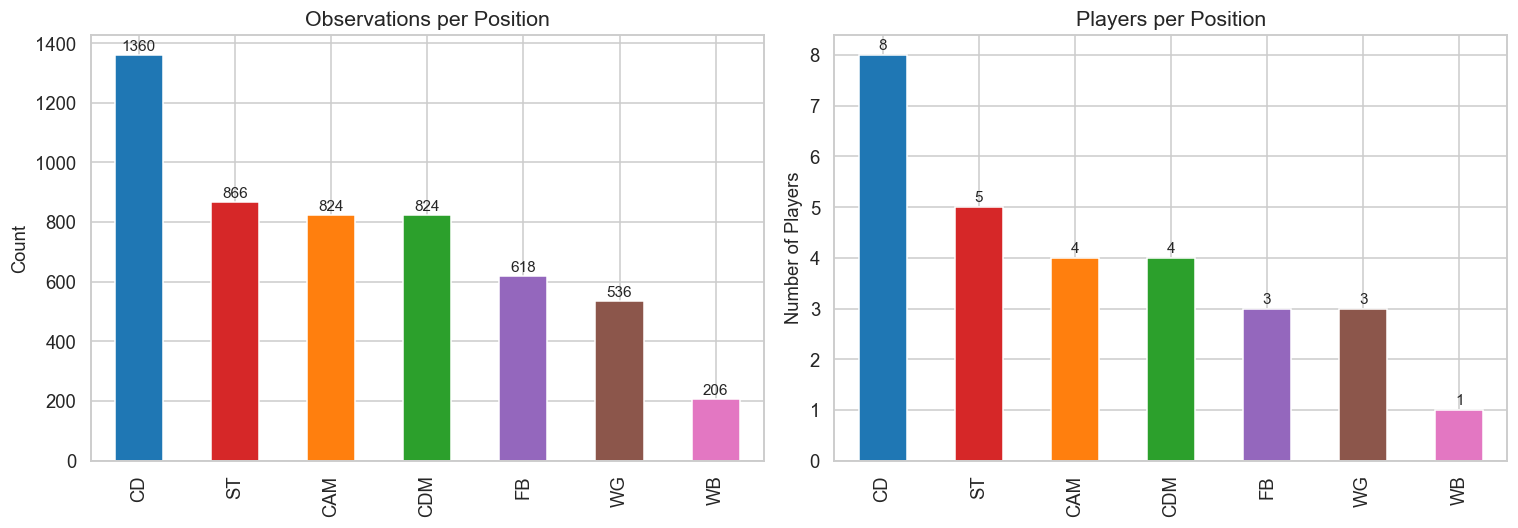

In [3]:
# Position distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

pos_counts = df['Position'].value_counts()
pos_counts.plot.bar(ax=axes[0], color=[POS_PALETTE.get(p, '#999') for p in pos_counts.index], edgecolor='white')
axes[0].set_title('Observations per Position')
axes[0].set_ylabel('Count')
axes[0].set_xlabel('')
for i, v in enumerate(pos_counts.values):
    axes[0].text(i, v + 15, str(v), ha='center', fontsize=10)

# Players per position
players_per_pos = df.groupby('Position')['Player ID'].nunique().sort_values(ascending=False)
players_per_pos.plot.bar(ax=axes[1], color=[POS_PALETTE.get(p, '#999') for p in players_per_pos.index], edgecolor='white')
axes[1].set_title('Players per Position')
axes[1].set_ylabel('Number of Players')
axes[1].set_xlabel('')
for i, v in enumerate(players_per_pos.values):
    axes[1].text(i, v + 0.1, str(v), ha='center', fontsize=10)

plt.tight_layout()
plt.show()

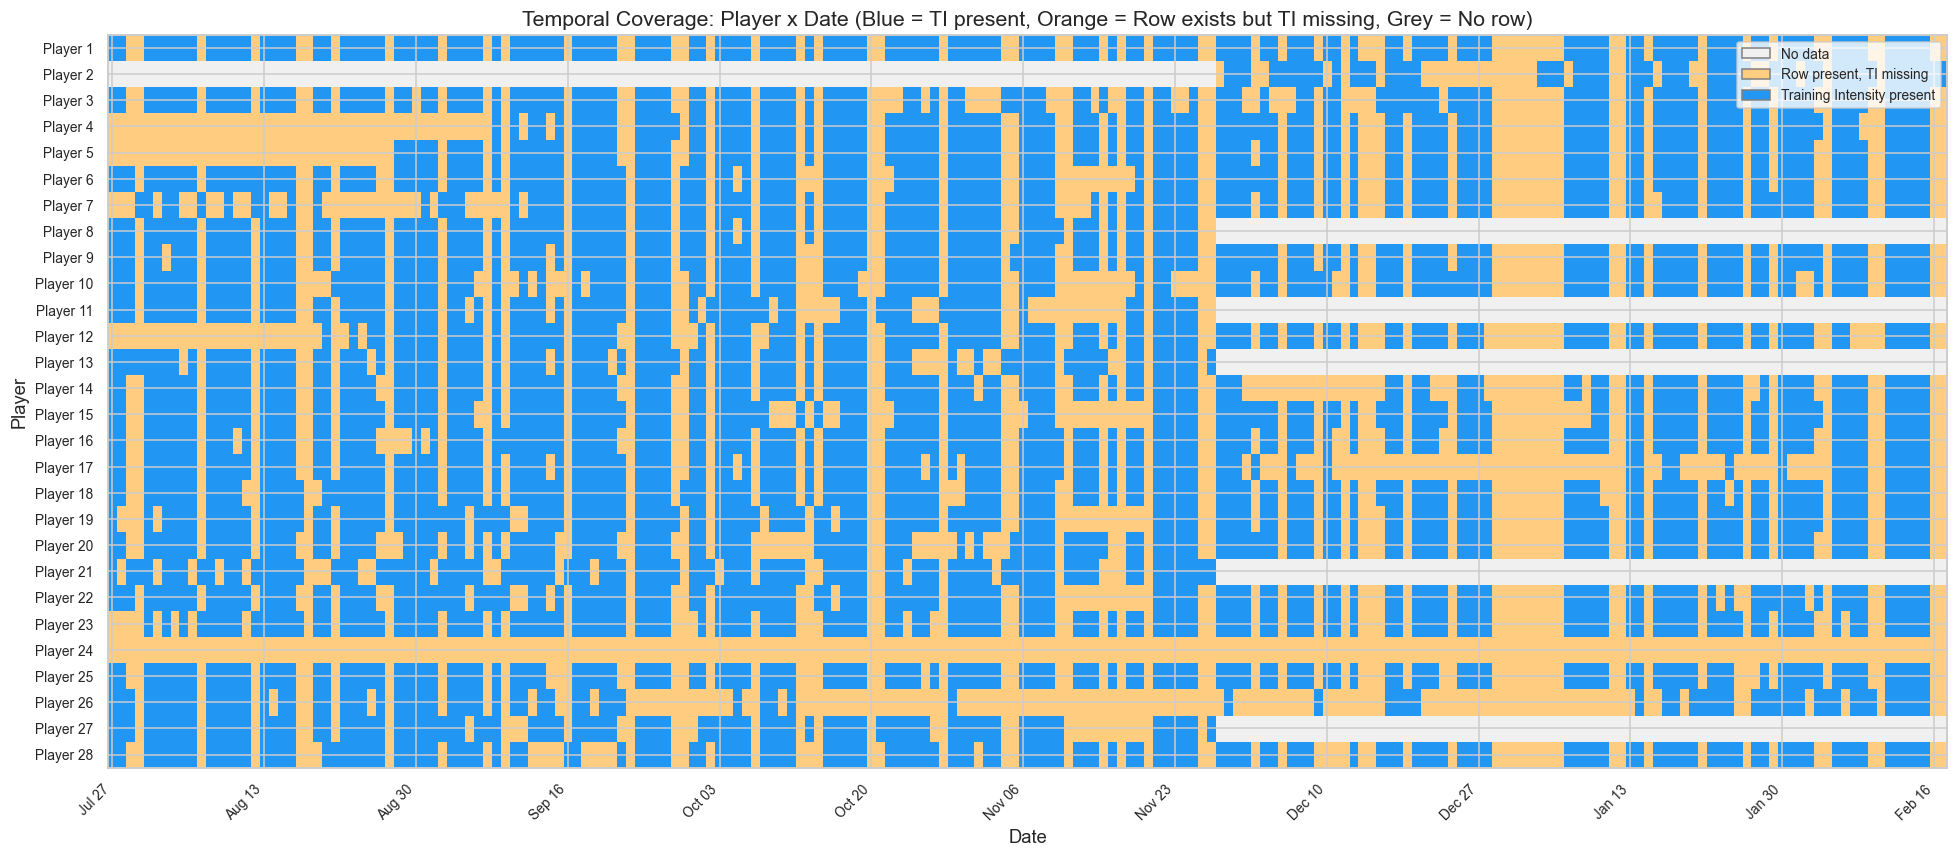

In [4]:
# Temporal coverage heatmap: player x date
fig, ax = plt.subplots(figsize=(18, 8))

# Pivot: rows=players, columns=dates, values=1 if present
# Use Activity Type Yesterday as a proxy for data richness
coverage = df.pivot_table(index='Player ID', columns='Date', values='Training Intensity Yesterday',
                          aggfunc=lambda x: 1 if x.notna().any() else 0)
coverage = coverage.fillna(0)

# Create a 3-level heatmap: 0=no data, 0.5=row exists but TI is NaN, 1=TI present
presence = df.pivot_table(index='Player ID', columns='Date', values='Status', aggfunc='count').fillna(0)
ti_present = df.pivot_table(index='Player ID', columns='Date', values='Training Intensity Yesterday',
                            aggfunc=lambda x: 1 if x.notna().any() else 0).fillna(0)

heatmap_data = presence.clip(upper=1) * 0.5 + ti_present * 0.5

cmap = plt.cm.colors.ListedColormap(['#f0f0f0', '#FFCC80', '#2196F3'])
bounds = [0, 0.25, 0.75, 1.01]
norm = plt.cm.colors.BoundaryNorm(bounds, cmap.N)

im = ax.imshow(heatmap_data.values, aspect='auto', cmap=cmap, norm=norm, interpolation='nearest')

# X axis: show ~10 date labels
dates = heatmap_data.columns
n_labels = 12
step = max(1, len(dates) // n_labels)
tick_positions = list(range(0, len(dates), step))
tick_labels = [dates[i].strftime('%b %d') for i in tick_positions]
ax.set_xticks(tick_positions)
ax.set_xticklabels(tick_labels, rotation=45, ha='right', fontsize=9)

ax.set_yticks(range(len(heatmap_data.index)))
ax.set_yticklabels([f'Player {i}' for i in heatmap_data.index], fontsize=9)
ax.set_xlabel('Date')
ax.set_ylabel('Player')
ax.set_title('Temporal Coverage: Player x Date (Blue = TI present, Orange = Row exists but TI missing, Grey = No row)')

legend_elements = [
    mpatches.Patch(facecolor='#f0f0f0', edgecolor='grey', label='No data'),
    mpatches.Patch(facecolor='#FFCC80', edgecolor='grey', label='Row present, TI missing'),
    mpatches.Patch(facecolor='#2196F3', edgecolor='grey', label='Training Intensity present'),
]
ax.legend(handles=legend_elements, loc='upper right', fontsize=9)

plt.tight_layout()
plt.show()

## 3. Missingness Analysis

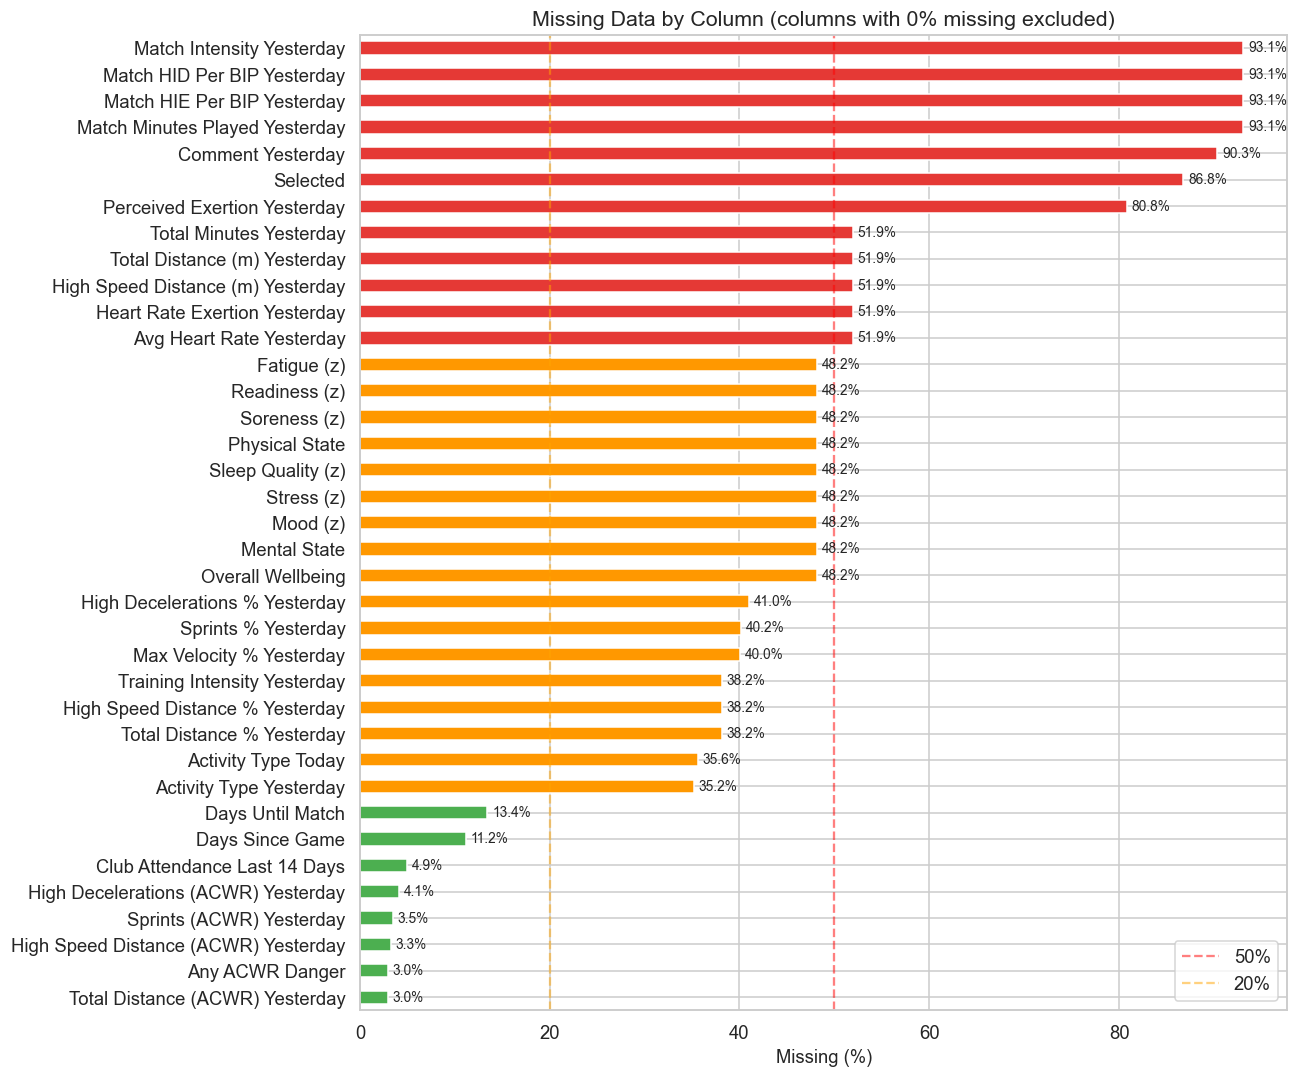

In [5]:
# Missingness bar chart for all columns (sorted)
missing = df.isna().sum()
missing_pct = 100 * missing / len(df)
missing_sorted = missing_pct[missing_pct > 0].sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(12, 10))
colors_bar = ['#E53935' if v > 50 else '#FF9800' if v > 20 else '#4CAF50' for v in missing_sorted.values]
missing_sorted.plot.barh(ax=ax, color=colors_bar, edgecolor='white')
ax.set_xlabel('Missing (%)')
ax.set_title('Missing Data by Column (columns with 0% missing excluded)')
ax.axvline(x=50, color='red', linestyle='--', alpha=0.5, label='50%')
ax.axvline(x=20, color='orange', linestyle='--', alpha=0.5, label='20%')

for i, (val, name) in enumerate(zip(missing_sorted.values, missing_sorted.index)):
    ax.text(val + 0.5, i, f'{val:.1f}%', va='center', fontsize=9)

ax.legend()
plt.tight_layout()
plt.show()

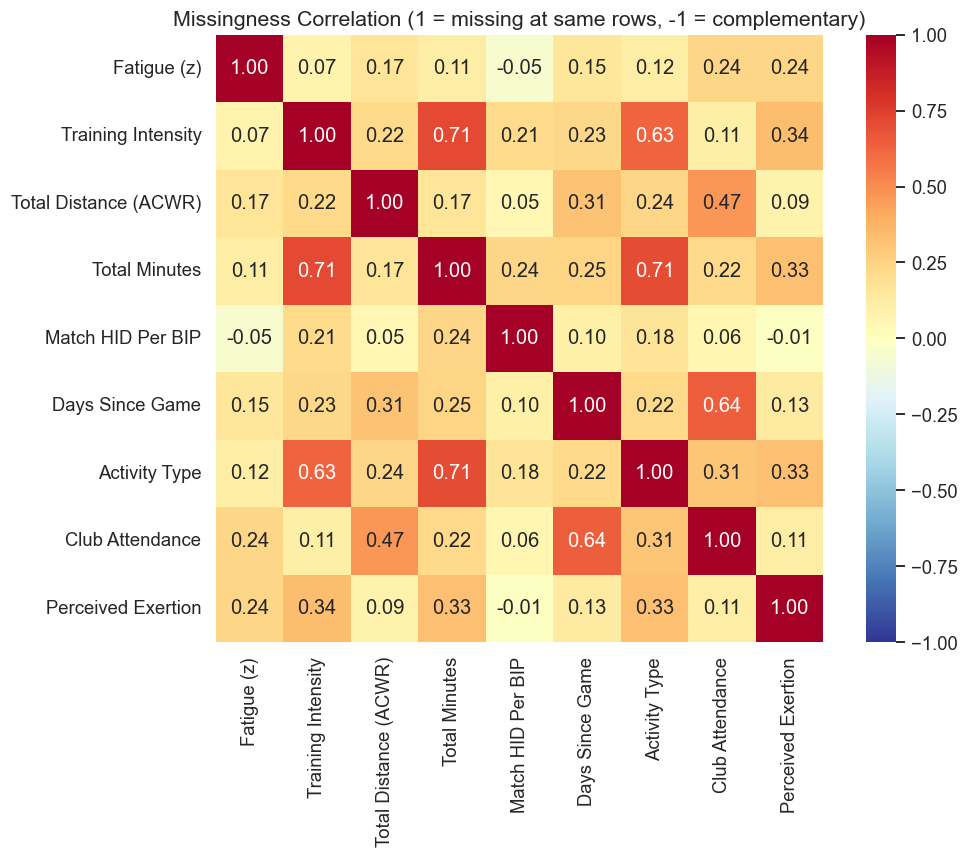

In [6]:
# Missingness correlation between key variable groups
miss_cols = [
    'Fatigue (z)', 'Training Intensity Yesterday',
    'Total Distance (ACWR) Yesterday', 'Total Minutes Yesterday',
    'Match HID Per BIP Yesterday', 'Days Since Game',
    'Activity Type Yesterday', 'Club Attendance Last 14 Days',
    'Perceived Exertion Yesterday'
]
miss_indicator = df[miss_cols].isna().astype(int)
miss_indicator.columns = [c.replace(' Yesterday', '').replace(' Last 14 Days', '') for c in miss_cols]

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(miss_indicator.corr(), annot=True, fmt='.2f', cmap='RdYlBu_r',
            center=0, vmin=-1, vmax=1, ax=ax, square=True)
ax.set_title('Missingness Correlation (1 = missing at same rows, -1 = complementary)')
plt.tight_layout()
plt.show()

## 4. Training Intensity Yesterday

Composite score: `tanh(mean(TD%, HSD%, Dec%, Sprints%) / 100)`  
Uses a **tanh soft cap** instead of hard clipping: the score approaches 1 asymptotically, so there is no pile-up at exactly 1.0.  

| GPS mean (% of match benchmark) | Score |
|---|---|
| 0% | 0.00 |
| 50% | 0.46 |
| 78% (typical training) | 0.65 |
| 100% (match-level load) | 0.76 |
| 130% (hard session) | 0.86 |
| 200% (very extreme) | 0.96 |

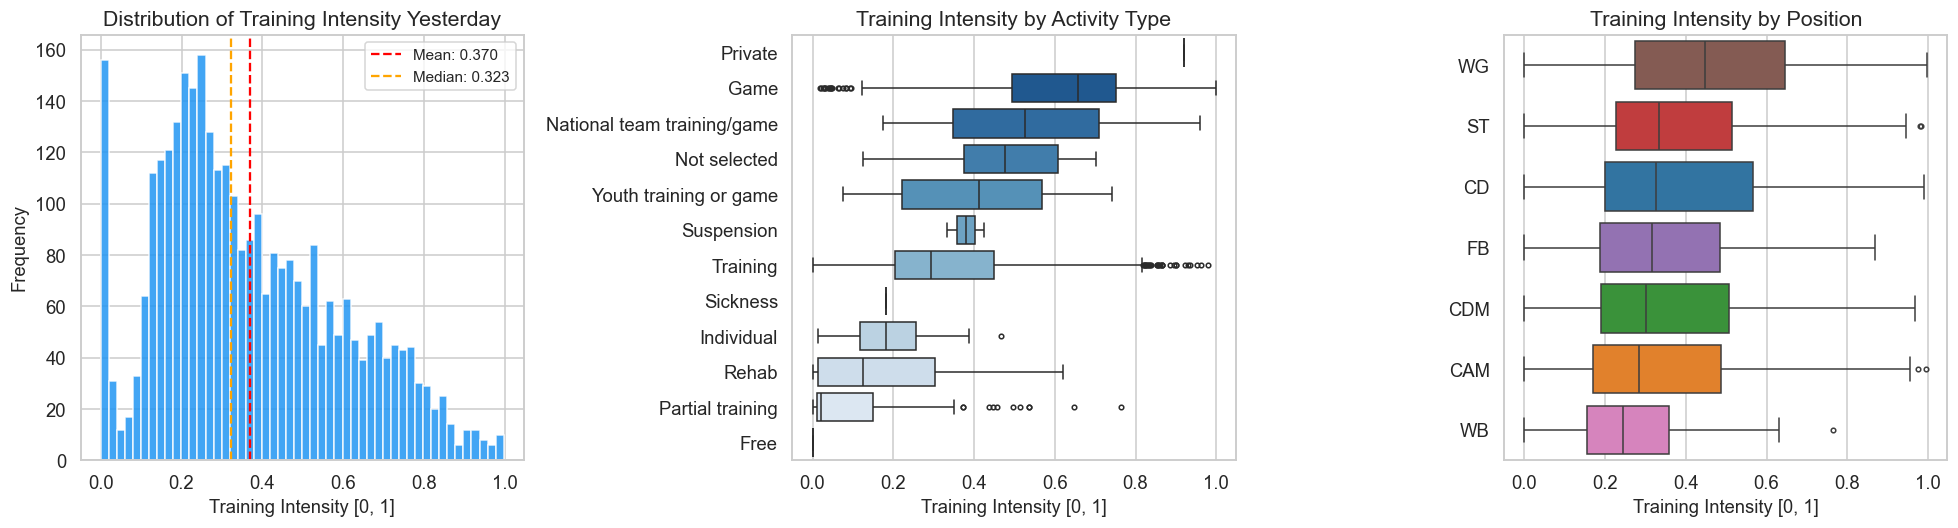

Training Intensity Yesterday: N=3,237, Mean=0.370, Median=0.323, Std=0.225, Min=0.000, Max=0.998


In [7]:
# Distribution of Training Intensity Yesterday
ti = df['Training Intensity Yesterday'].dropna()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Histogram
axes[0].hist(ti, bins=50, color='#2196F3', edgecolor='white', alpha=0.85)
axes[0].axvline(ti.mean(), color='red', linestyle='--', linewidth=1.5, label=f'Mean: {ti.mean():.3f}')
axes[0].axvline(ti.median(), color='orange', linestyle='--', linewidth=1.5, label=f'Median: {ti.median():.3f}')
axes[0].set_xlabel('Training Intensity [0, 1]')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Training Intensity Yesterday')
axes[0].legend(fontsize=10)

# Box plot by Activity Type Yesterday
ti_data = df.dropna(subset=['Training Intensity Yesterday', 'Activity Type Yesterday'])
activity_order = ti_data.groupby('Activity Type Yesterday')['Training Intensity Yesterday'].median().sort_values(ascending=False).index
sns.boxplot(data=ti_data, y='Activity Type Yesterday', x='Training Intensity Yesterday',
            order=activity_order, ax=axes[1], palette='Blues_r', fliersize=3)
axes[1].set_title('Training Intensity by Activity Type')
axes[1].set_xlabel('Training Intensity [0, 1]')
axes[1].set_ylabel('')

# Box plot by Position
pos_order = df.groupby('Position')['Training Intensity Yesterday'].median().sort_values(ascending=False).index
sns.boxplot(data=df, y='Position', x='Training Intensity Yesterday',
            order=pos_order, ax=axes[2],
            palette=[POS_PALETTE.get(p, '#999') for p in pos_order], fliersize=3)
axes[2].set_title('Training Intensity by Position')
axes[2].set_xlabel('Training Intensity [0, 1]')
axes[2].set_ylabel('')

plt.tight_layout()
plt.show()

print(f'Training Intensity Yesterday: N={len(ti):,}, Mean={ti.mean():.3f}, Median={ti.median():.3f}, '
      f'Std={ti.std():.3f}, Min={ti.min():.3f}, Max={ti.max():.3f}')

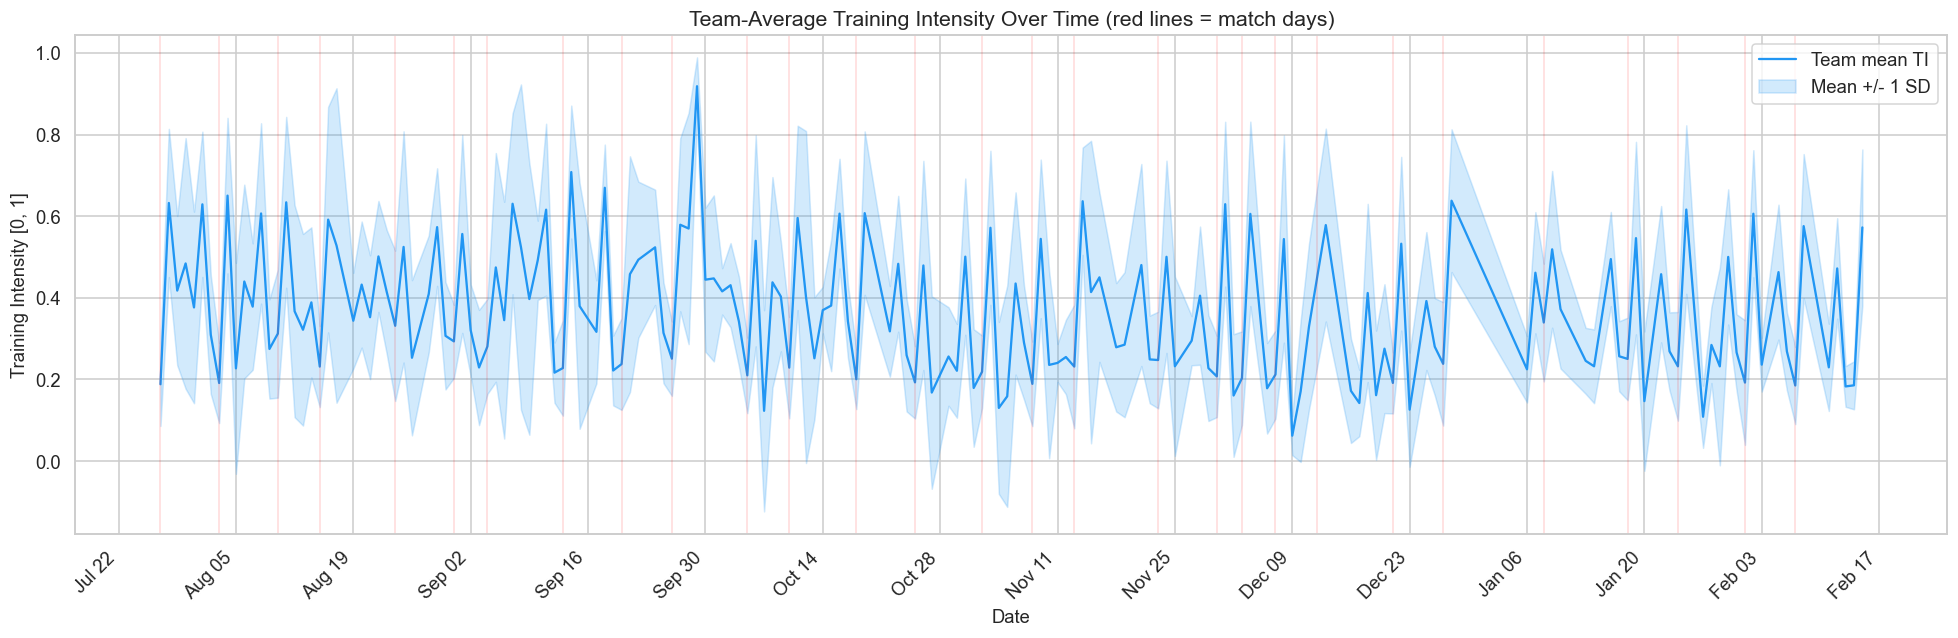

In [8]:
# Training Intensity over time (team-level daily average)
daily_ti = df.groupby('Date')['Training Intensity Yesterday'].agg(['mean', 'std', 'count'])
daily_ti = daily_ti[daily_ti['count'] >= 3]  # At least 3 players reporting

fig, ax = plt.subplots(figsize=(18, 6))
ax.plot(daily_ti.index, daily_ti['mean'], color='#2196F3', linewidth=1.5, label='Team mean TI')
ax.fill_between(daily_ti.index,
                daily_ti['mean'] - daily_ti['std'],
                daily_ti['mean'] + daily_ti['std'],
                alpha=0.2, color='#2196F3', label='Mean +/- 1 SD')

# Mark match days
match_dates = df[df['Match Day'] == 1]['Date'].unique()
for md in match_dates:
    ax.axvline(md, color='red', alpha=0.15, linewidth=1)

ax.set_xlabel('Date')
ax.set_ylabel('Training Intensity [0, 1]')
ax.set_title('Team-Average Training Intensity Over Time (red lines = match days)')
ax.legend(loc='upper right')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

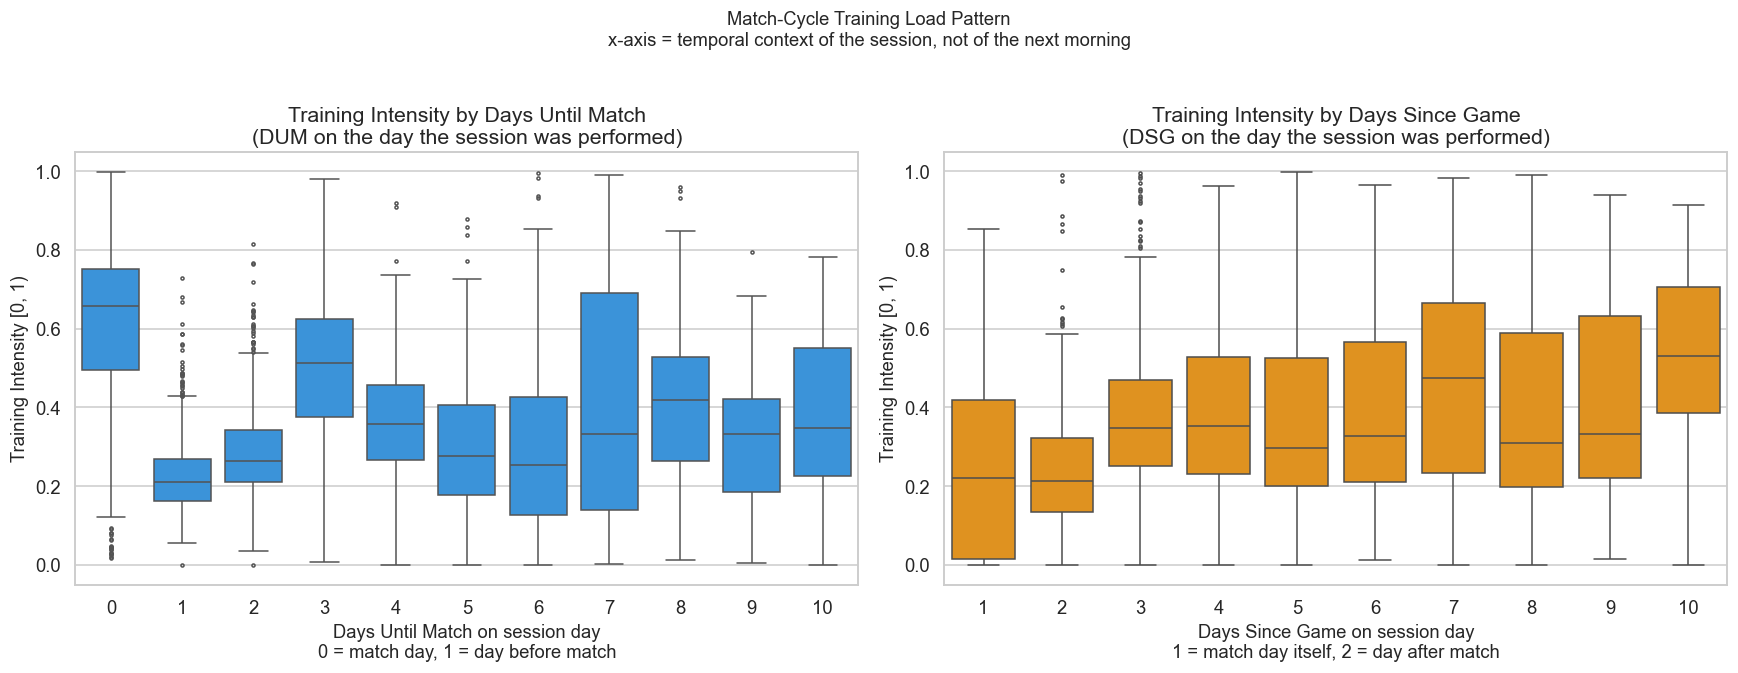

DUM analysis: 2,555 rows (sessions with valid DUM <= 10)
DSG analysis: 2,457 rows (sessions with valid DSG <= 10)


In [9]:
# Training Intensity by Match Cycle Position
#
# TEMPORAL STRUCTURE:
#   Training Intensity Yesterday = session that occurred on day t-1.
#   Days Until Match (DUM) and Days Since Game (DSG) are morning-of-t variables.
#
#   When today's DUM = 3, yesterday's session was performed at DUM = 4.
#   Using today's DUM as the x-axis would shift every session one day closer
#   to the match than it actually was.
#
#   FIX: recover the DUM/DSG that applied on the day the session occurred
#   by shifting both columns back one row (per player, sorted by date).

df_sorted = df.sort_values(['Player ID', 'Date']).copy()
df_sorted['DUM_session'] = df_sorted.groupby('Player ID')['Days Until Match'].shift(1)
df_sorted['DSG_session'] = df_sorted.groupby('Player ID')['Days Since Game'].shift(1)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: TI Yesterday grouped by DUM on the session day
ti_by_dum = df_sorted.dropna(subset=['Training Intensity Yesterday', 'DUM_session'])
ti_by_dum = ti_by_dum[ti_by_dum['DUM_session'] <= 10]
ti_by_dum = ti_by_dum.copy()
ti_by_dum['DUM_session'] = ti_by_dum['DUM_session'].astype(int)
sns.boxplot(data=ti_by_dum, x='DUM_session', y='Training Intensity Yesterday',
            ax=axes[0], color='#2196F3', fliersize=2)
axes[0].set_title('Training Intensity by Days Until Match\n'
                  '(DUM on the day the session was performed)')
axes[0].set_ylabel('Training Intensity [0, 1)')
axes[0].set_xlabel('Days Until Match on session day\n0 = match day, 1 = day before match')

# Right: TI Yesterday grouped by DSG on the session day
ti_by_dsg = df_sorted.dropna(subset=['Training Intensity Yesterday', 'DSG_session'])
ti_by_dsg = ti_by_dsg[ti_by_dsg['DSG_session'] <= 10]
ti_by_dsg = ti_by_dsg.copy()
ti_by_dsg['DSG_session'] = ti_by_dsg['DSG_session'].astype(int)
sns.boxplot(data=ti_by_dsg, x='DSG_session', y='Training Intensity Yesterday',
            ax=axes[1], color='#FF9800', fliersize=2)
axes[1].set_title('Training Intensity by Days Since Game\n'
                  '(DSG on the day the session was performed)')
axes[1].set_ylabel('Training Intensity [0, 1)')
axes[1].set_xlabel('Days Since Game on session day\n1 = match day itself, 2 = day after match')

plt.suptitle('Match-Cycle Training Load Pattern\n'
             'x-axis = temporal context of the session, not of the next morning',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

# Summary counts
print(f'DUM analysis: {len(ti_by_dum):,} rows (sessions with valid DUM <= 10)')
print(f'DSG analysis: {len(ti_by_dsg):,} rows (sessions with valid DSG <= 10)')

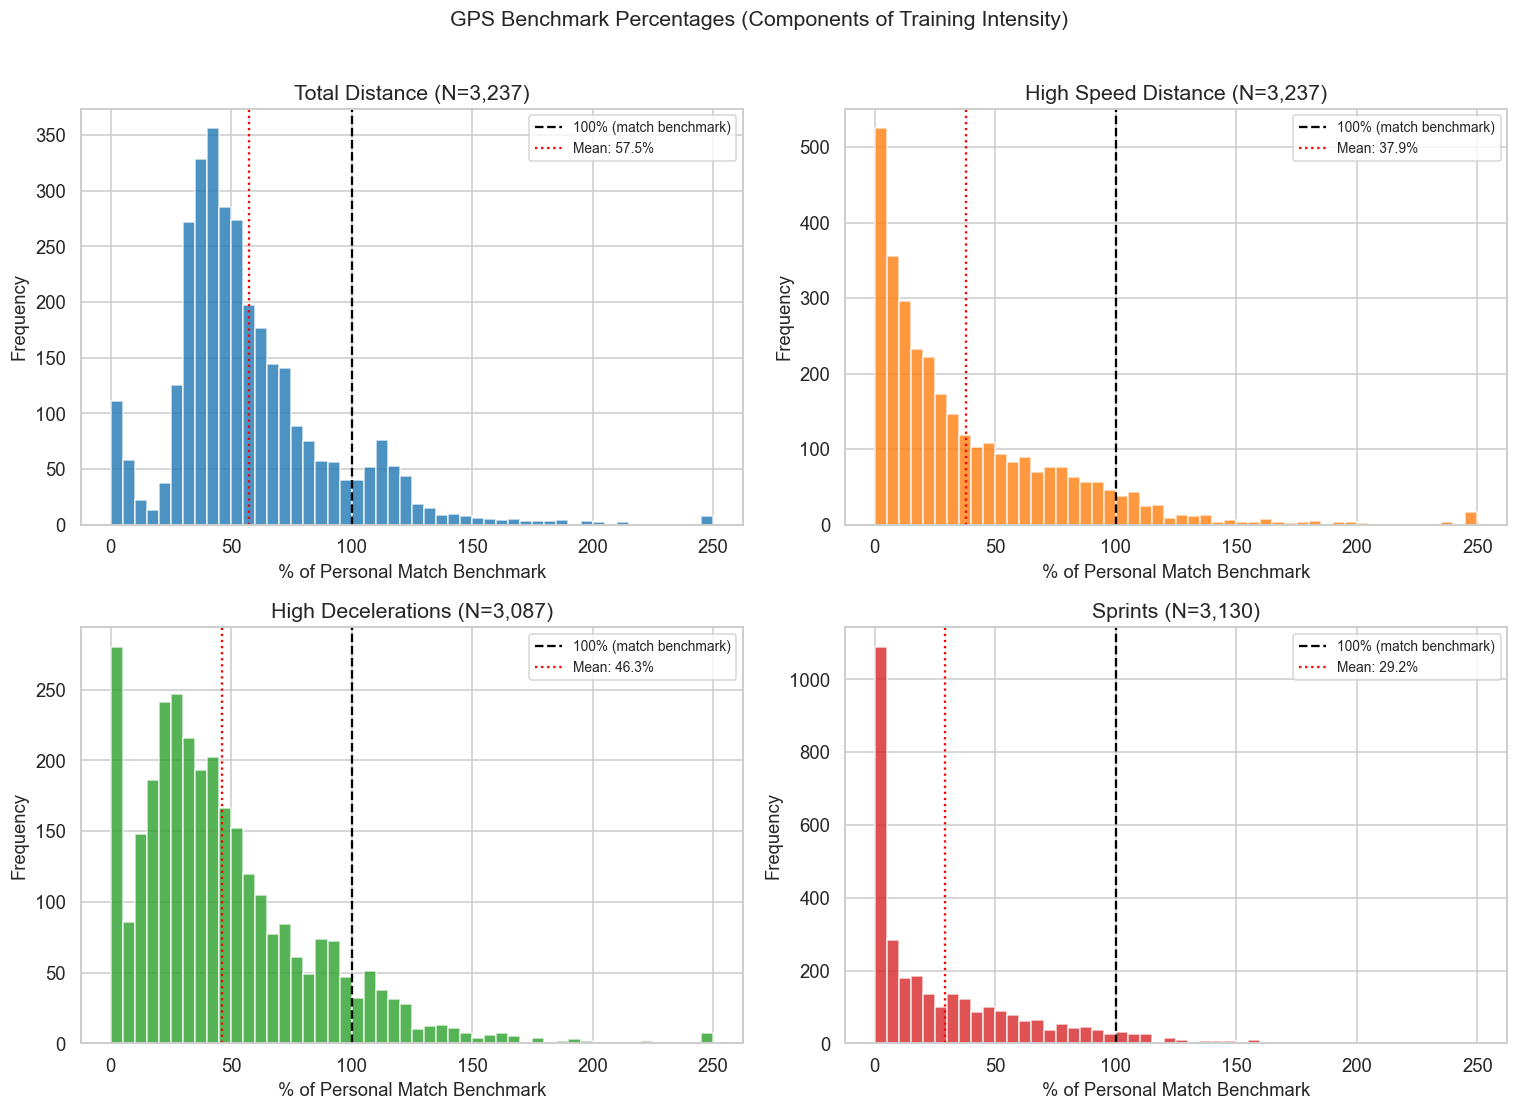

In [10]:
# GPS % component distributions and their contribution to Training Intensity
gps_pct_cols = [
    'Total Distance % Yesterday', 'High Speed Distance % Yesterday',
    'High Decelerations % Yesterday', 'Sprints % Yesterday'
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
colors_gps = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

for idx, (col, color) in enumerate(zip(gps_pct_cols, colors_gps)):
    ax = axes[idx // 2, idx % 2]
    vals = df[col].dropna()
    ax.hist(vals, bins=50, color=color, edgecolor='white', alpha=0.8)
    ax.axvline(100, color='black', linestyle='--', linewidth=1.5, label='100% (match benchmark)')
    ax.axvline(vals.mean(), color='red', linestyle=':', linewidth=1.5, label=f'Mean: {vals.mean():.1f}%')
    short_name = col.replace(' % Yesterday', '').replace(' Yesterday', '')
    ax.set_title(f'{short_name} (N={len(vals):,})')
    ax.set_xlabel('% of Personal Match Benchmark')
    ax.set_ylabel('Frequency')
    ax.legend(fontsize=9)

plt.suptitle('GPS Benchmark Percentages (Components of Training Intensity)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

C:\Users\U0152019\AppData\Local\Temp\ipykernel_9784\2918533172.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


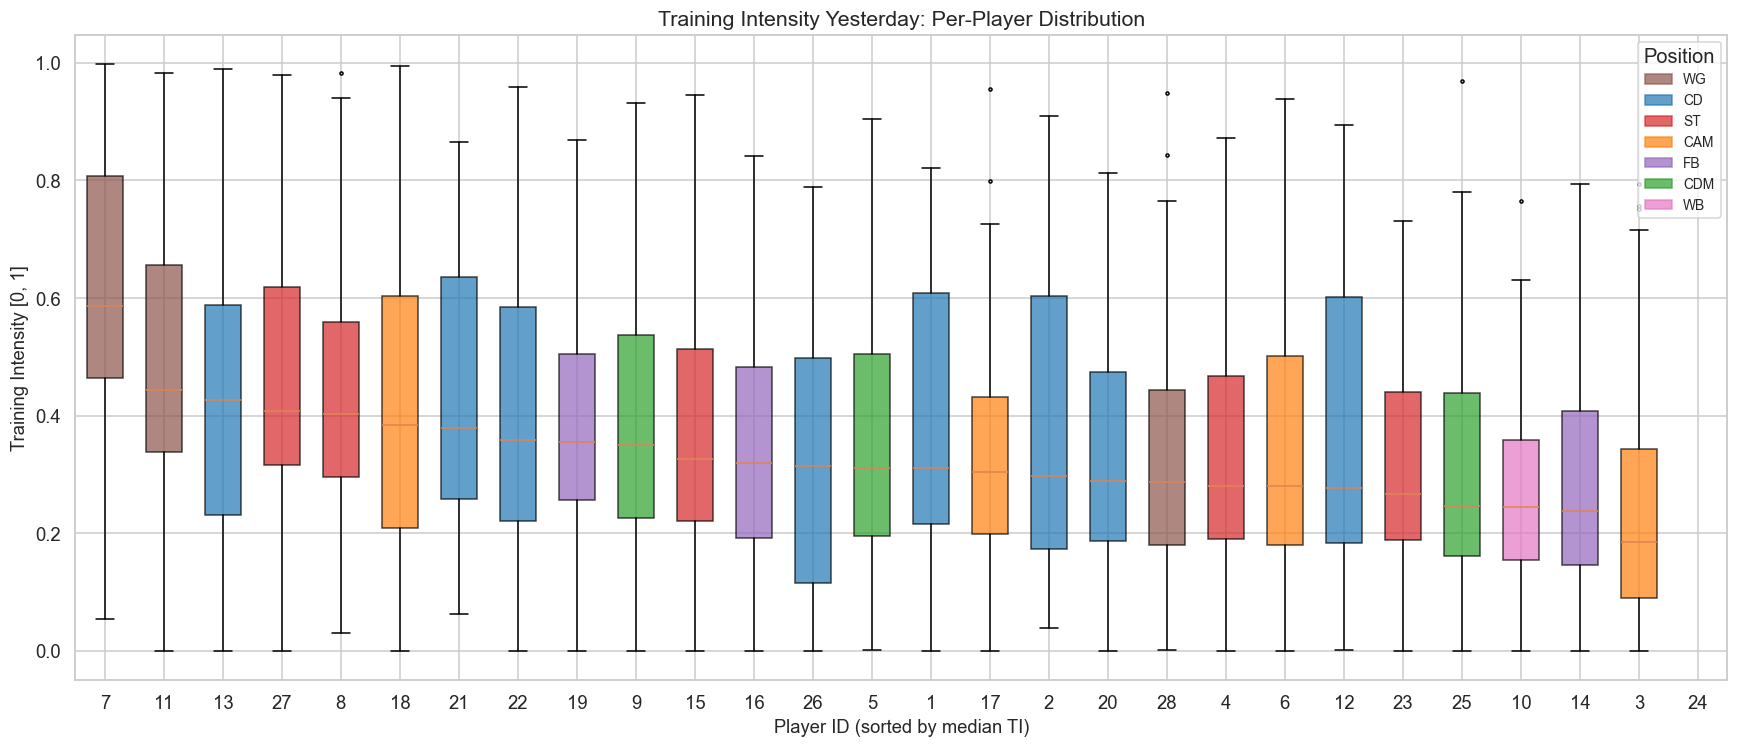

In [11]:
# Per-player Training Intensity distributions
fig, ax = plt.subplots(figsize=(16, 7))

player_order = df.groupby('Player ID')['Training Intensity Yesterday'].median().sort_values(ascending=False).index
player_positions = df.drop_duplicates('Player ID').set_index('Player ID')['Position']
box_colors = [POS_PALETTE.get(player_positions.get(p, ''), '#999') for p in player_order]

bp = ax.boxplot(
    [df[df['Player ID'] == p]['Training Intensity Yesterday'].dropna().values for p in player_order],
    labels=[str(p) for p in player_order],
    patch_artist=True, flierprops=dict(markersize=2), widths=0.6
)
for patch, color in zip(bp['boxes'], box_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

# Position legend
used_positions = player_positions.reindex(player_order).unique()
legend_patches = [mpatches.Patch(color=POS_PALETTE.get(p, '#999'), label=p, alpha=0.7) for p in used_positions]
ax.legend(handles=legend_patches, title='Position', loc='upper right', fontsize=9)

ax.set_xlabel('Player ID (sorted by median TI)')
ax.set_ylabel('Training Intensity [0, 1]')
ax.set_title('Training Intensity Yesterday: Per-Player Distribution')
plt.tight_layout()
plt.show()

## 5. Match Performance Variables

Four variables from the Games dataset, available only on the **day after a match**:
- **Match HID Per BIP**: High-intensity distance per Ball-In-Play minute (m)
- **Match HIE Per BIP**: High-intensity efforts per Ball-In-Play minute  
- **Match Minutes Played**: Total minutes played in the match
- **Match Intensity**: Causal outcome Y — `sqrt(HID × HIE) × sqrt(clip(minutes, 15, 90) / 90)`. Geometric mean of the two per-BIP metrics, weighted by playing time (capped at 60 min so full-game players receive weight 1).

In [12]:
match_cols = [
    'Match HID Per BIP Yesterday',
    'Match HIE Per BIP Yesterday',
    'Match Minutes Played Yesterday',
    'Match Intensity Yesterday',
]
match_data = df.dropna(subset=['Match HID Per BIP Yesterday', 'Match HIE Per BIP Yesterday',
                               'Match Minutes Played Yesterday'])

print(f'Rows with match performance data: {len(match_data):,} out of {len(df):,} ({100*len(match_data)/len(df):.1f}%)')
print(f'Unique players with match data: {match_data["Player ID"].nunique()}')
print(f'Unique match dates: {match_data["Date"].nunique()}')
print()
display(match_data[match_cols].describe().round(2))

Rows with match performance data: 362 out of 5,234 (6.9%)
Unique players with match data: 23
Unique match dates: 25



,Match HID Per BIP Yesterday,Match HIE Per BIP Yesterday,Match Minutes Played Yesterday,Match Intensity Yesterday
count,362.00,362.00,362.00,362.00
mean,18.80,1.02,68.18,3.41
std,7.83,0.37,31.92,1.16
min,6.08,0.31,3.05,1.08
25%,13.16,0.77,35.76,2.59
50%,17.26,0.98,78.04,3.34
75%,23.01,1.23,97.55,4.11
max,59.11,3.81,107.75,7.11


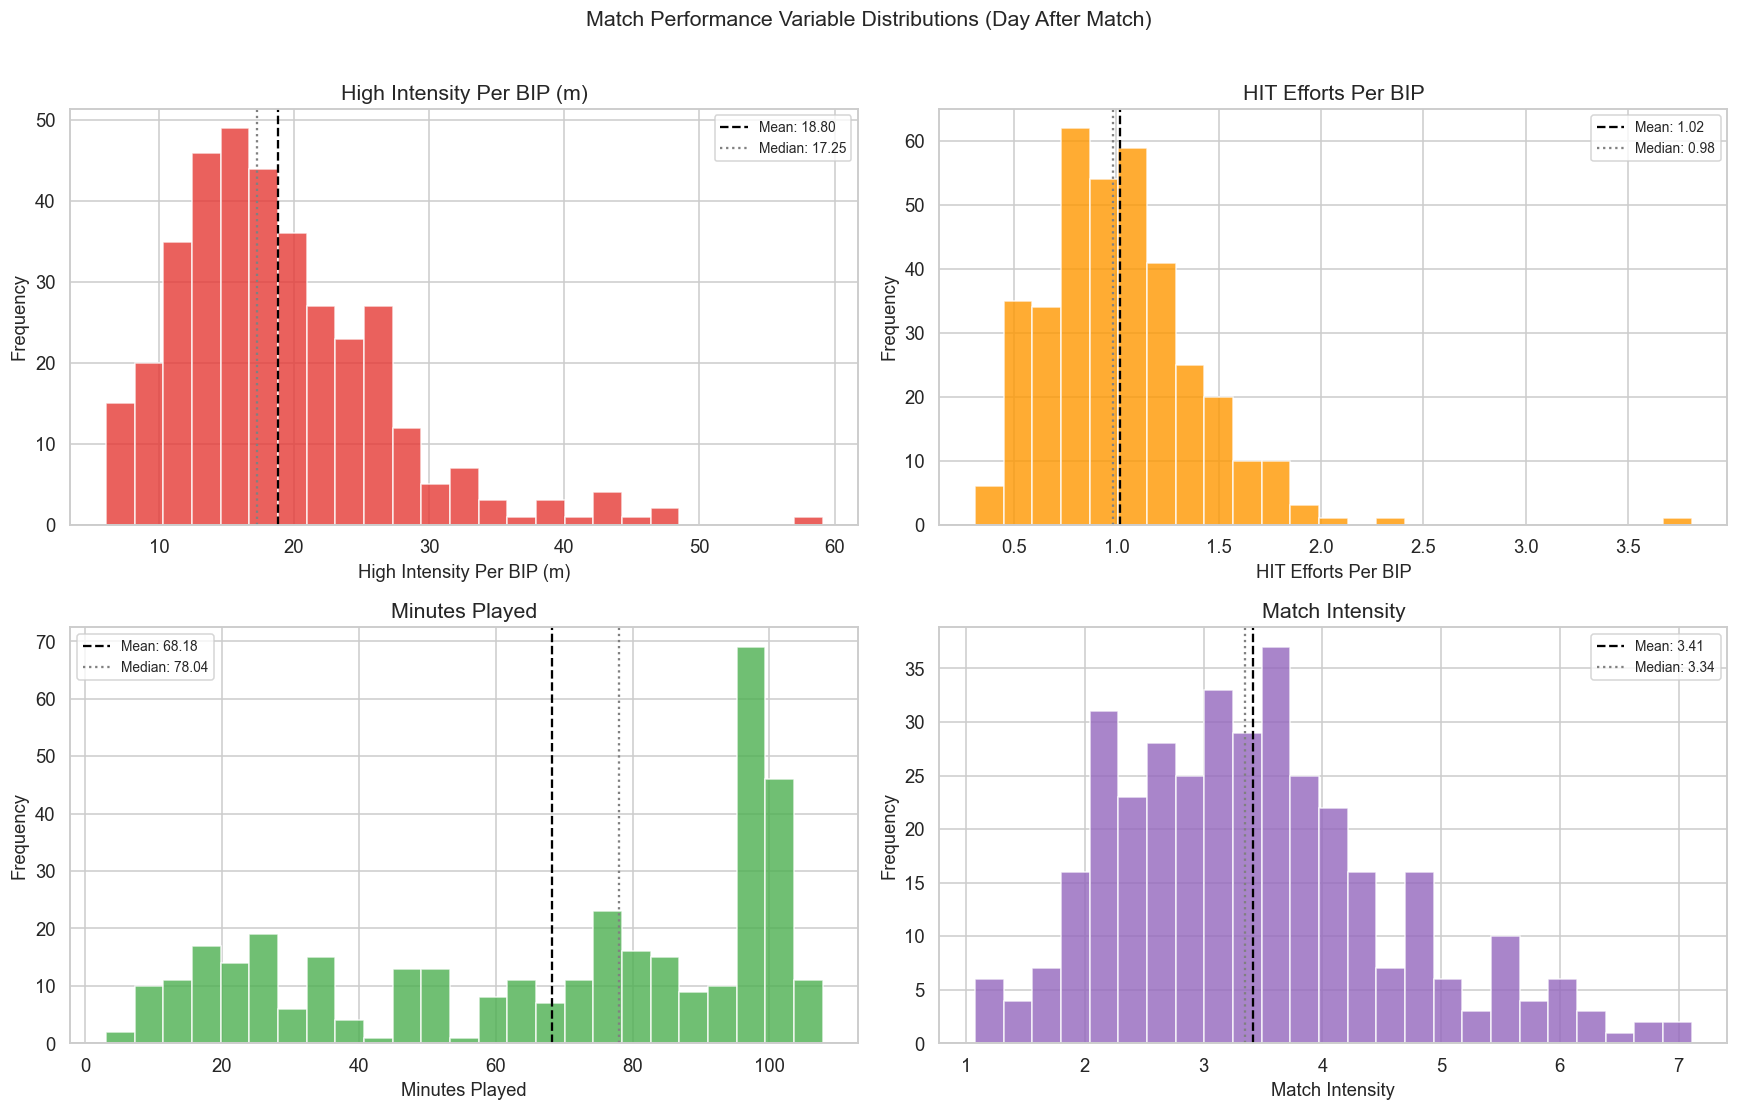

In [13]:
# Match performance distributions
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()
match_colors = ['#E53935', '#FF9800', '#4CAF50', '#9467bd']
match_labels = ['High Intensity Per BIP (m)', 'HIT Efforts Per BIP', 'Minutes Played', 'Match Intensity']

for idx, (col, color, label) in enumerate(zip(match_cols, match_colors, match_labels)):
    ax = axes[idx]
    vals = match_data[col].dropna()
    ax.hist(vals, bins=25, color=color, edgecolor='white', alpha=0.8)
    ax.axvline(vals.mean(), color='black', linestyle='--', linewidth=1.5, label=f'Mean: {vals.mean():.2f}')
    ax.axvline(vals.median(), color='grey', linestyle=':', linewidth=1.5, label=f'Median: {vals.median():.2f}')
    ax.set_title(label)
    ax.set_xlabel(label)
    ax.set_ylabel('Frequency')
    ax.legend(fontsize=9)

plt.suptitle('Match Performance Variable Distributions (Day After Match)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

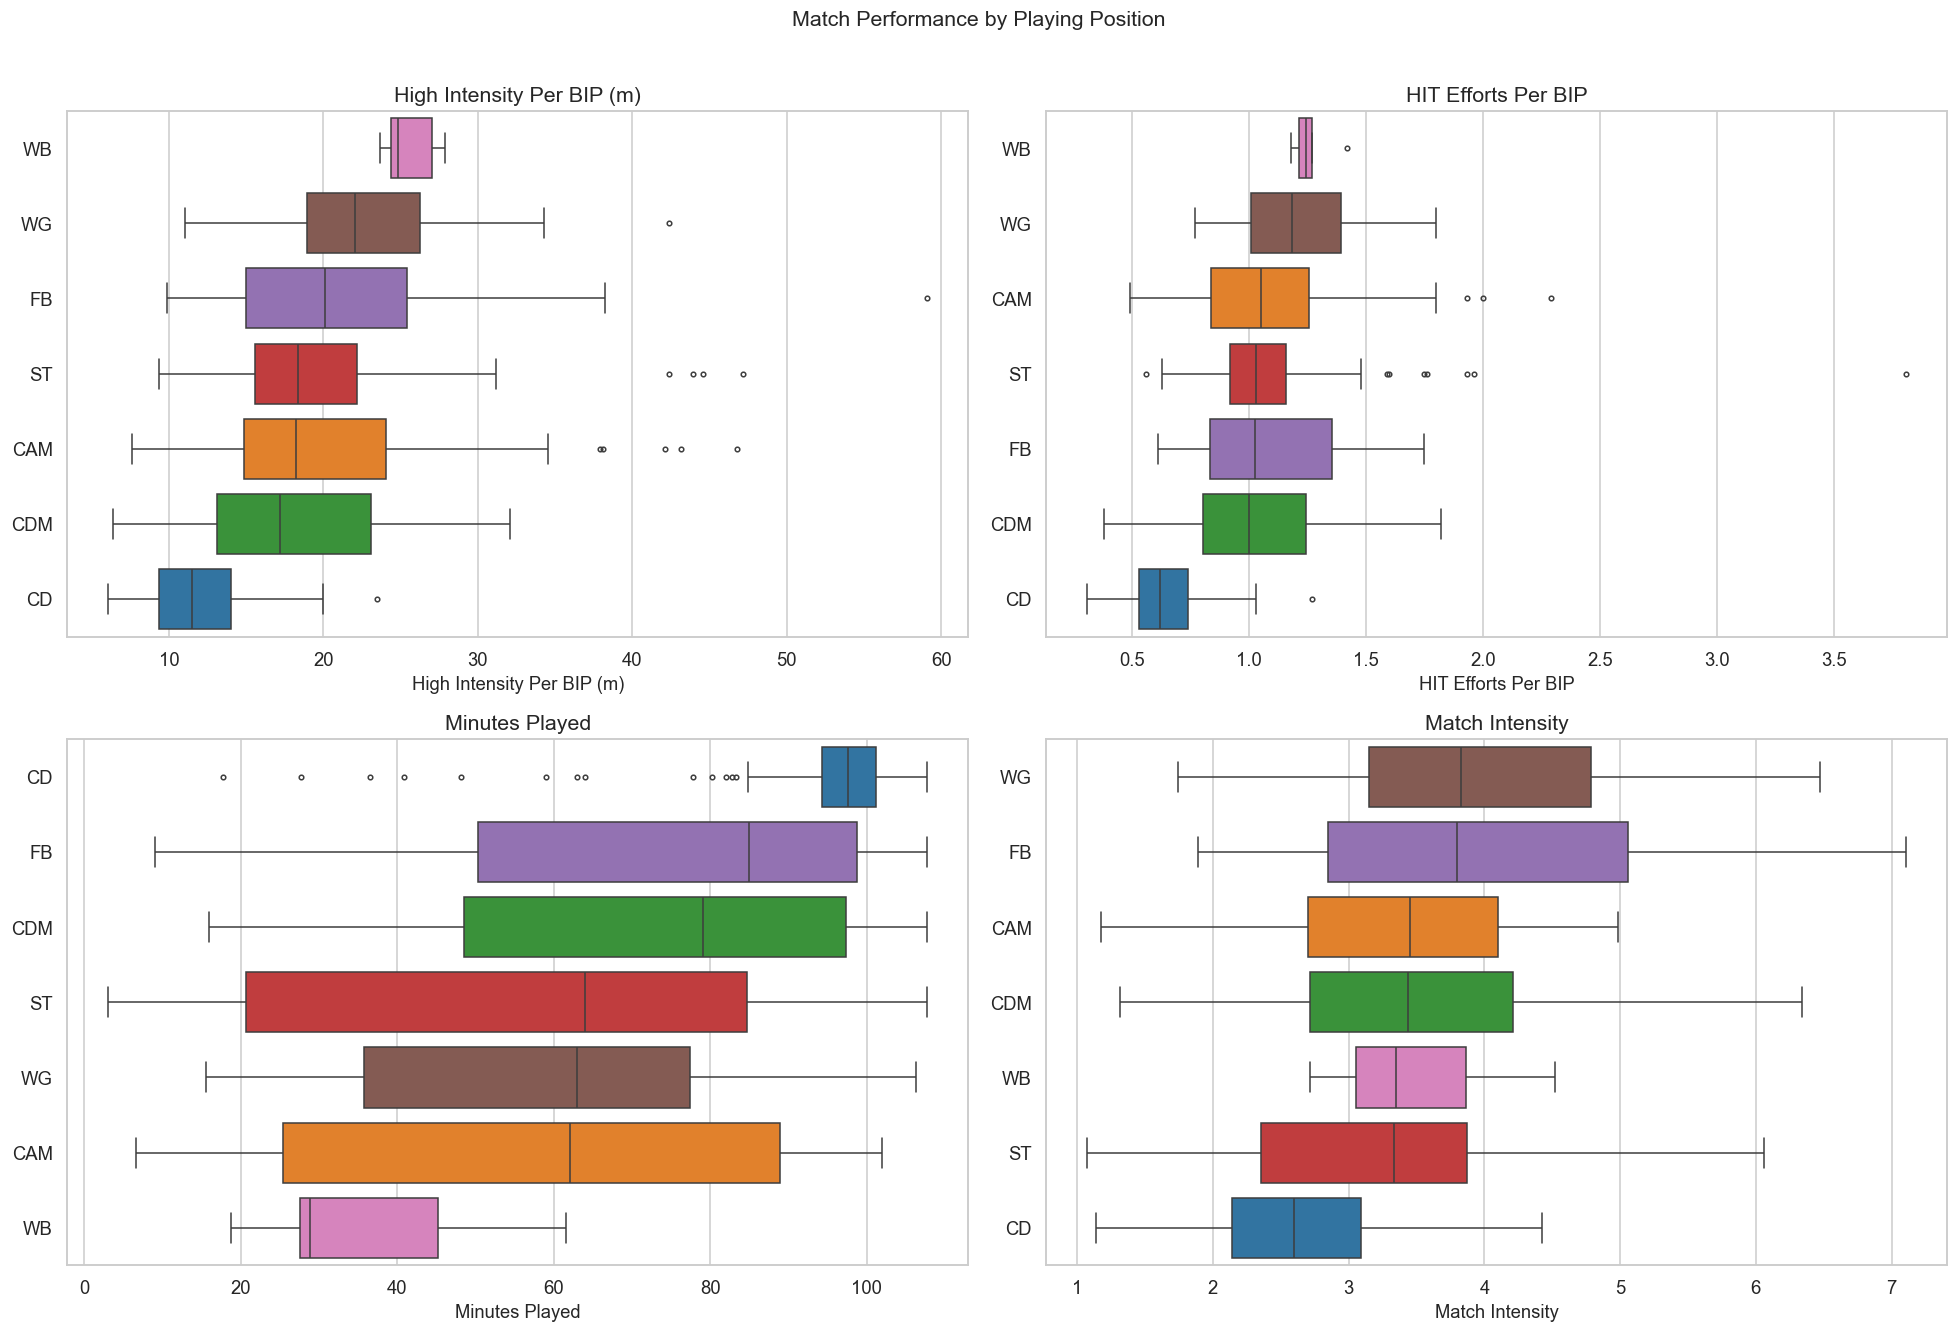

In [14]:
# Match performance by position
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
axes = axes.flatten()

for idx, (col, label) in enumerate(zip(match_cols, match_labels)):
    ax = axes[idx]
    plot_data = match_data.dropna(subset=[col])
    pos_order_match = plot_data.groupby('Position')[col].median().sort_values(ascending=False).index
    sns.boxplot(data=plot_data, y='Position', x=col, order=pos_order_match,
                palette=[POS_PALETTE.get(p, '#999') for p in pos_order_match],
                ax=ax, fliersize=3)
    ax.set_title(label)
    ax.set_xlabel(label)
    ax.set_ylabel('')

plt.suptitle('Match Performance by Playing Position', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

C:\Users\U0152019\AppData\Local\Temp\ipykernel_9784\832939988.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(box_data_filtered, labels=labels_filtered,


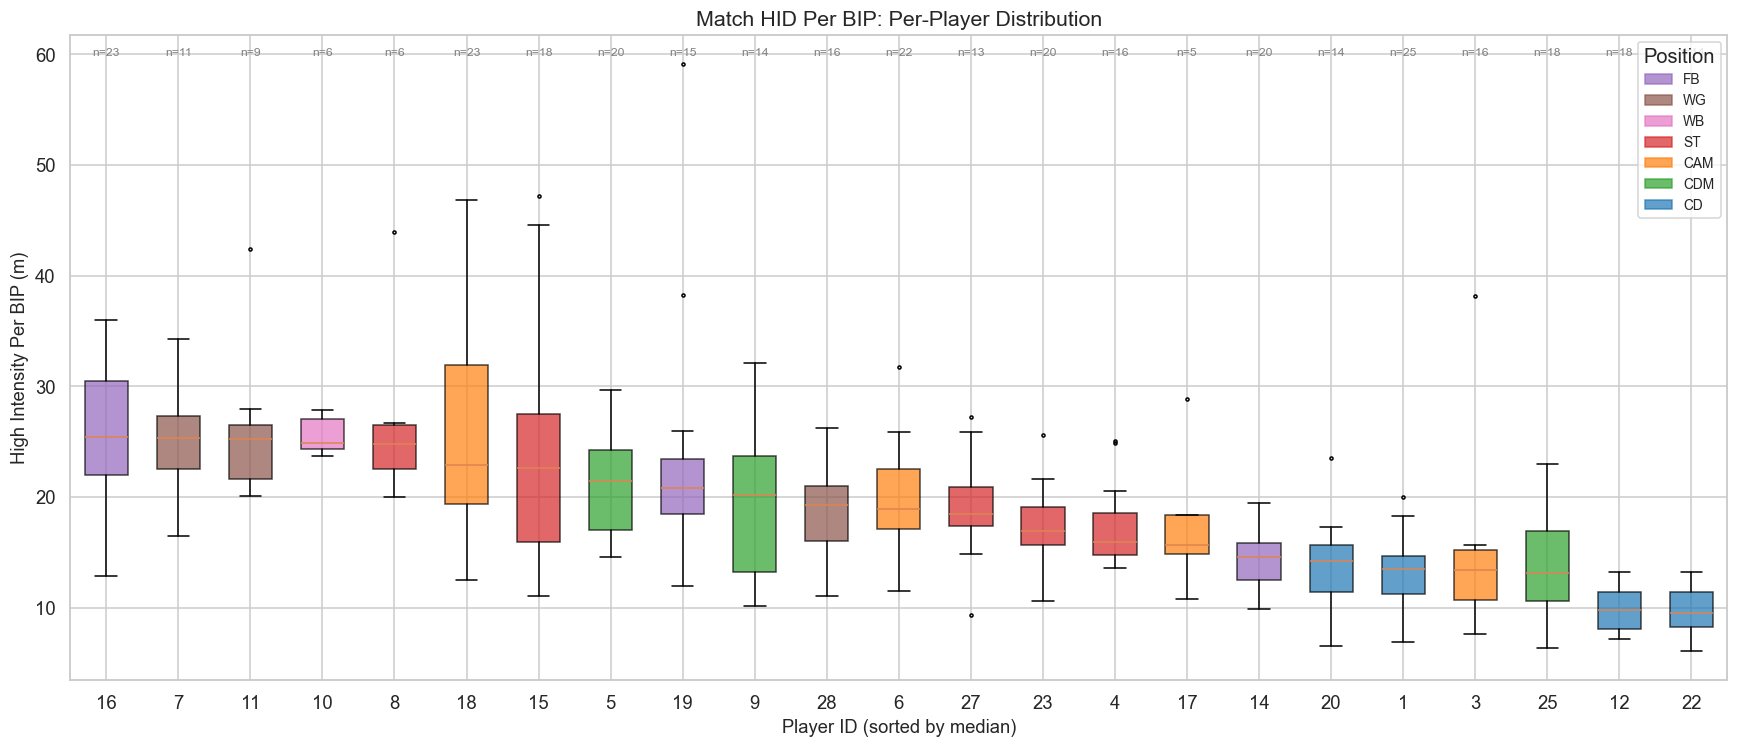

In [15]:
# Per-player match performance (High Intensity Per BIP)
fig, ax = plt.subplots(figsize=(16, 7))

player_match_median = match_data.groupby('Player ID')['Match HID Per BIP Yesterday'].median()
player_order_match = player_match_median.sort_values(ascending=False).index
player_positions = df.drop_duplicates('Player ID').set_index('Player ID')['Position']

box_data = [match_data[match_data['Player ID'] == p]['Match HID Per BIP Yesterday'].values
            for p in player_order_match]
# Filter out players with no match data
valid_mask = [len(d) > 0 for d in box_data]
box_data_filtered = [d for d, v in zip(box_data, valid_mask) if v]
labels_filtered = [str(p) for p, v in zip(player_order_match, valid_mask) if v]
colors_filtered = [POS_PALETTE.get(player_positions.get(p, ''), '#999') for p, v in zip(player_order_match, valid_mask) if v]

bp = ax.boxplot(box_data_filtered, labels=labels_filtered,
                patch_artist=True, flierprops=dict(markersize=2), widths=0.6)
for patch, color in zip(bp['boxes'], colors_filtered):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

# Match count as text on top
for i, (p, v) in enumerate(zip(player_order_match, valid_mask)):
    if v:
        n = len(match_data[match_data['Player ID'] == p])
        ax.text(list(player_order_match).index(p) - sum(1 for x in valid_mask[:list(player_order_match).index(p)] if not x) + 1,
                ax.get_ylim()[1] * 0.97, f'n={n}', ha='center', fontsize=8, color='grey')

used_positions = player_positions.reindex([p for p, v in zip(player_order_match, valid_mask) if v]).unique()
legend_patches = [mpatches.Patch(color=POS_PALETTE.get(p, '#999'), label=p, alpha=0.7) for p in used_positions]
ax.legend(handles=legend_patches, title='Position', loc='upper right', fontsize=9)

ax.set_xlabel('Player ID (sorted by median)')
ax.set_ylabel('High Intensity Per BIP (m)')
ax.set_title('Match HID Per BIP: Per-Player Distribution')
plt.tight_layout()
plt.show()

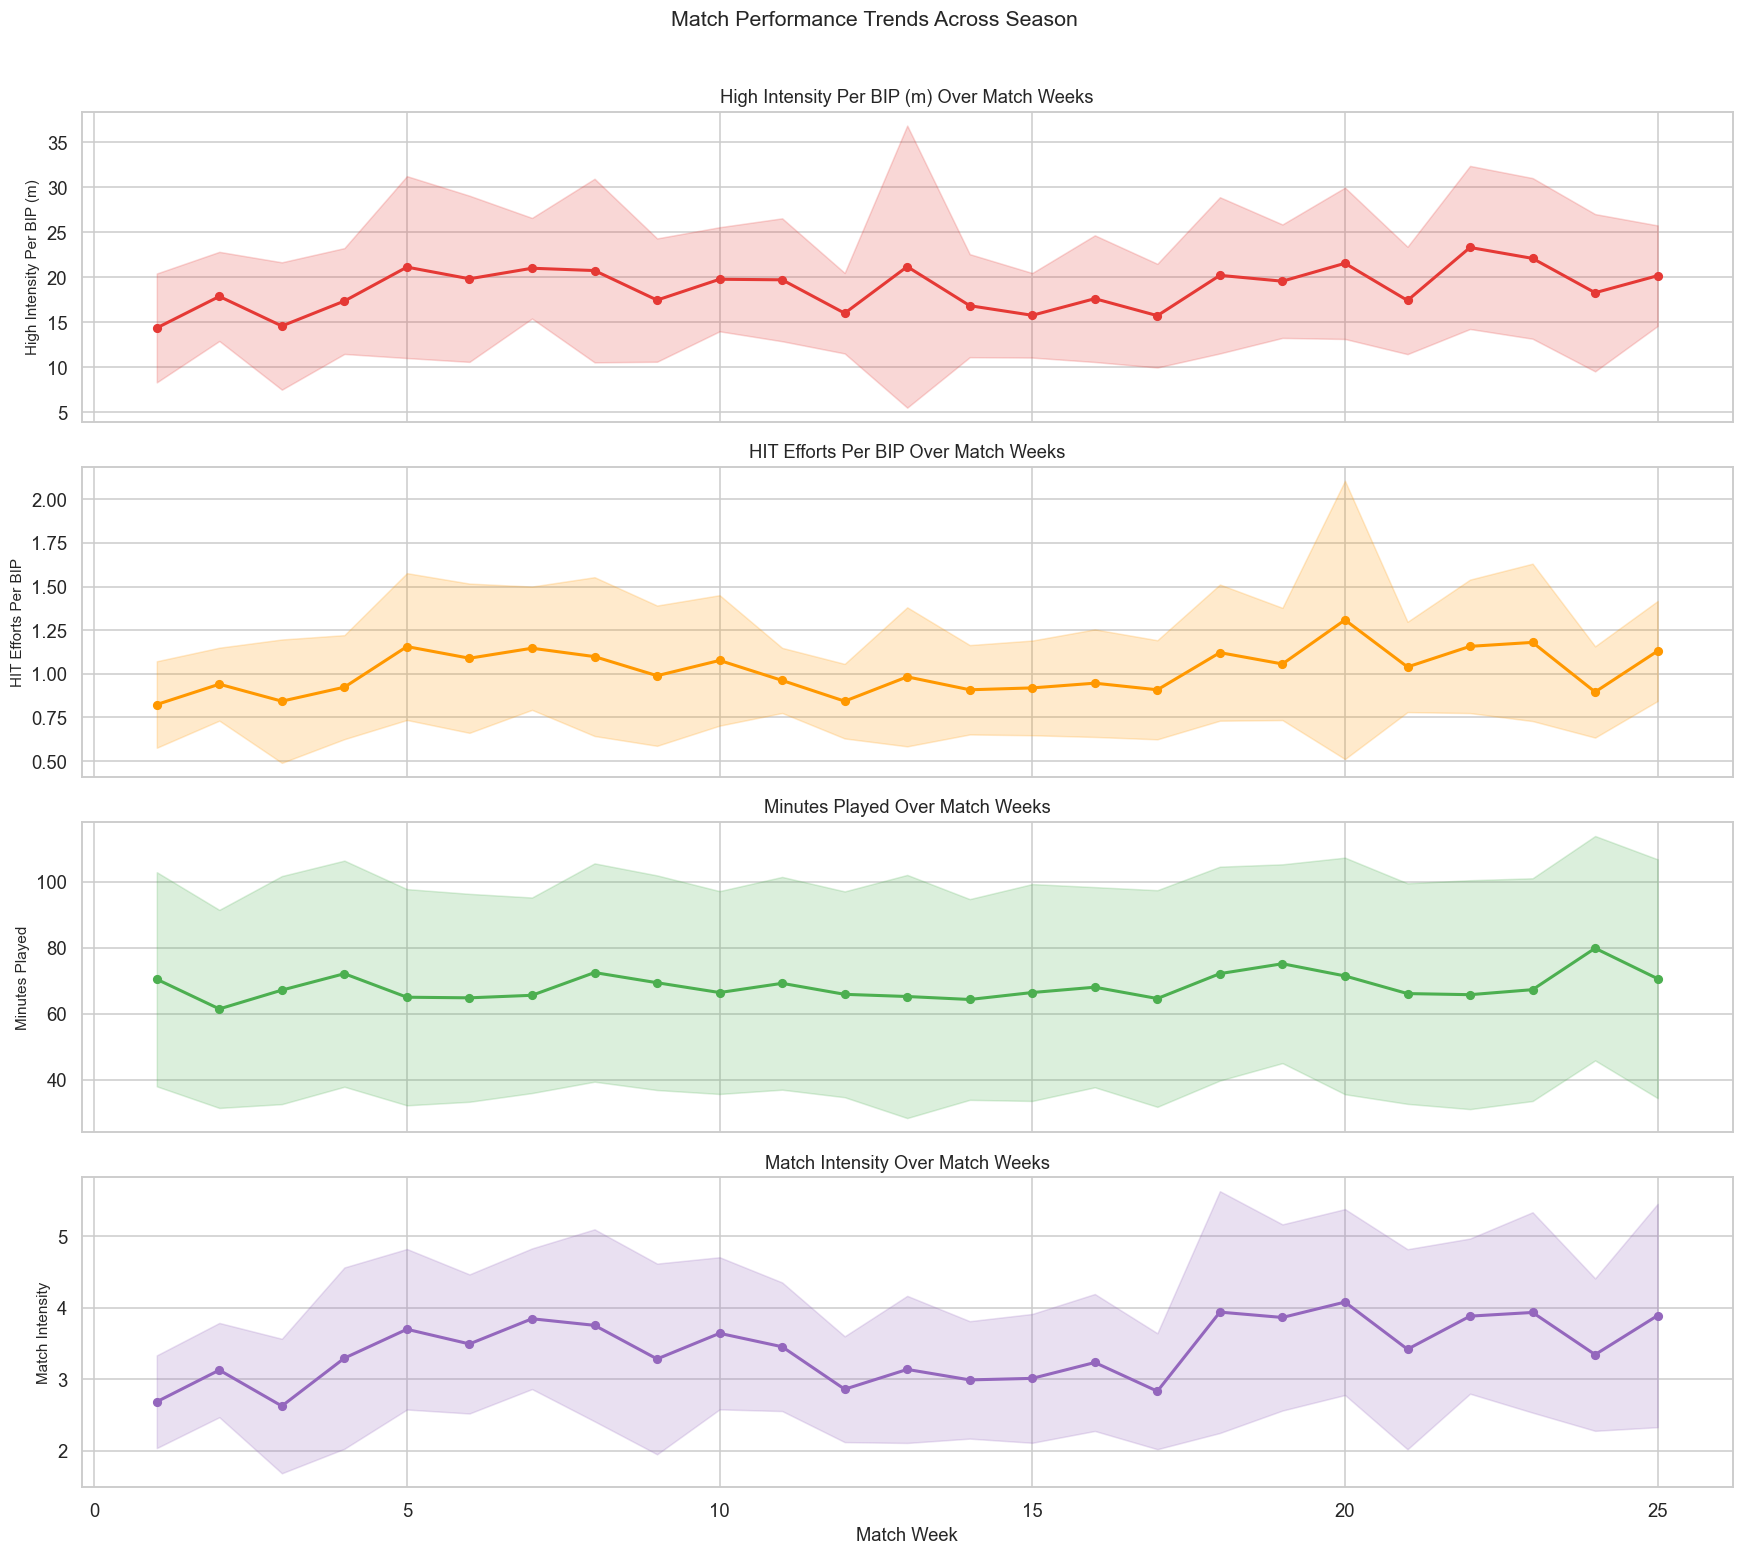

In [16]:
# Match performance over time (across match weeks)
match_data_sorted = match_data.sort_values('Date')
match_dates_unique = match_data_sorted['Date'].unique()
match_date_map = {d: i+1 for i, d in enumerate(match_dates_unique)}
match_data_sorted = match_data_sorted.copy()
match_data_sorted['Match Week'] = match_data_sorted['Date'].map(match_date_map)

fig, axes = plt.subplots(4, 1, figsize=(16, 14), sharex=True)

for idx, (col, label, color) in enumerate(zip(match_cols, match_labels, match_colors)):
    ax = axes[idx]
    plot_sorted = match_data_sorted.dropna(subset=[col])
    weekly_stats = plot_sorted.groupby('Match Week')[col].agg(['mean', 'std'])
    ax.plot(weekly_stats.index, weekly_stats['mean'], color=color, linewidth=2, marker='o', markersize=5)
    ax.fill_between(weekly_stats.index,
                    weekly_stats['mean'] - weekly_stats['std'],
                    weekly_stats['mean'] + weekly_stats['std'],
                    alpha=0.2, color=color)
    ax.set_ylabel(label, fontsize=10)
    ax.set_title(f'{label} Over Match Weeks', fontsize=12)

axes[-1].set_xlabel('Match Week')
plt.suptitle('Match Performance Trends Across Season', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

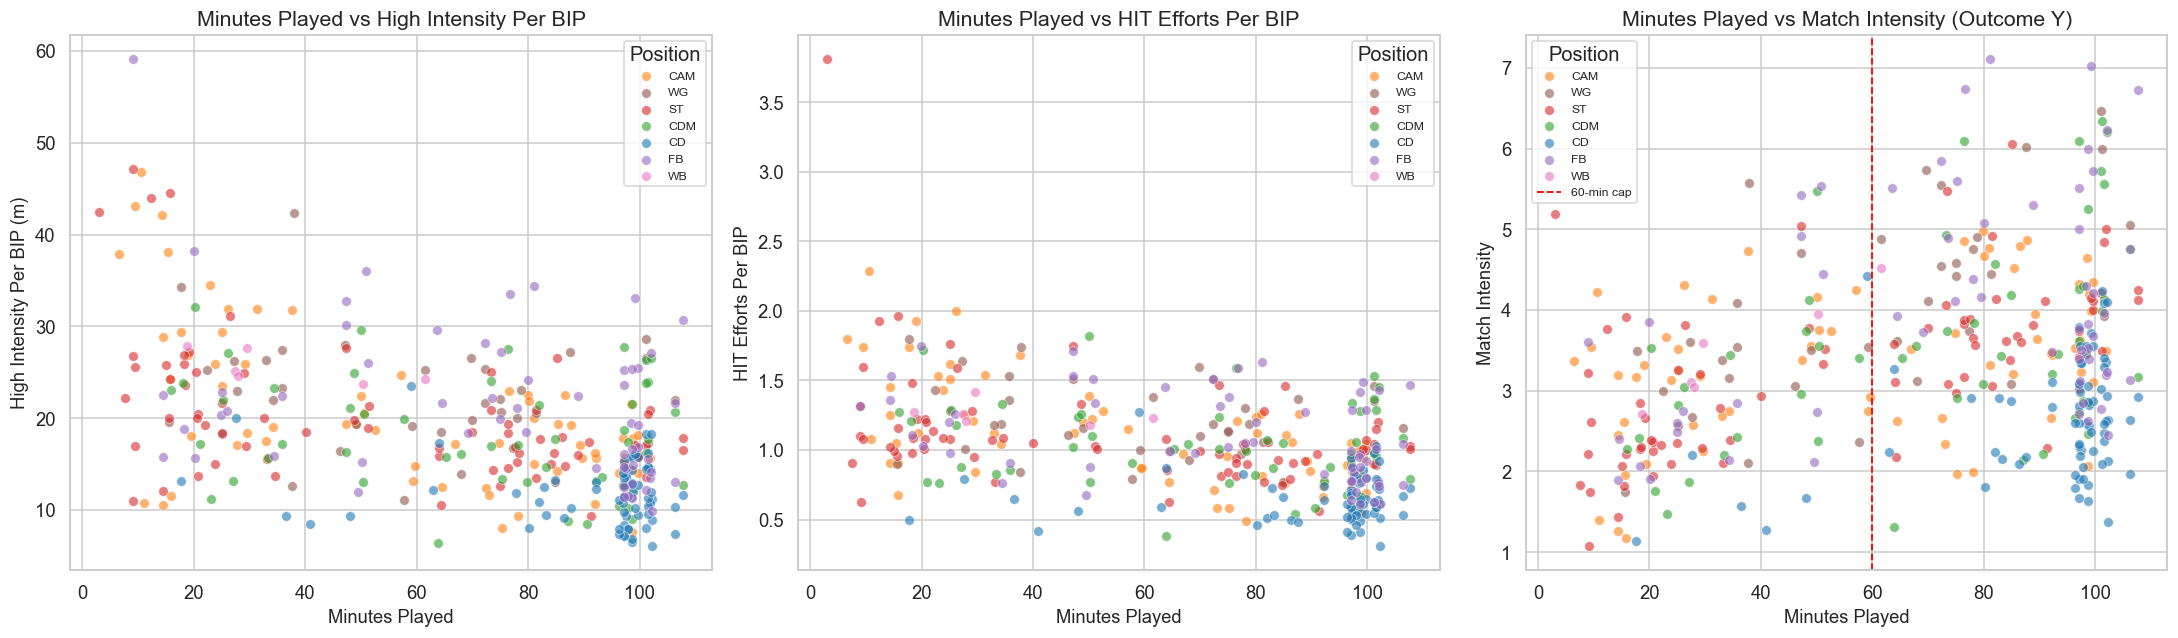

In [17]:
# Relationship between minutes played and intensity metrics
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

ax = axes[0]
for pos in match_data['Position'].unique():
    pos_data = match_data[match_data['Position'] == pos]
    ax.scatter(pos_data['Match Minutes Played Yesterday'],
              pos_data['Match HID Per BIP Yesterday'],
              color=POS_PALETTE.get(pos, '#999'), label=pos, alpha=0.6, s=40,
              edgecolors='white', linewidth=0.5)
ax.set_xlabel('Minutes Played')
ax.set_ylabel('High Intensity Per BIP (m)')
ax.set_title('Minutes Played vs High Intensity Per BIP')
ax.legend(title='Position', fontsize=8)

ax = axes[1]
for pos in match_data['Position'].unique():
    pos_data = match_data[match_data['Position'] == pos]
    ax.scatter(pos_data['Match Minutes Played Yesterday'],
              pos_data['Match HIE Per BIP Yesterday'],
              color=POS_PALETTE.get(pos, '#999'), label=pos, alpha=0.6, s=40,
              edgecolors='white', linewidth=0.5)
ax.set_xlabel('Minutes Played')
ax.set_ylabel('HIT Efforts Per BIP')
ax.set_title('Minutes Played vs HIT Efforts Per BIP')
ax.legend(title='Position', fontsize=8)

# Match Intensity vs Minutes: the weight cap at 60 min dampens
# inflated per-BIP values from short-stint substitutes
ax = axes[2]
for pos in match_data['Position'].unique():
    pos_data = match_data[match_data['Position'] == pos].dropna(subset=['Match Intensity Yesterday'])
    ax.scatter(pos_data['Match Minutes Played Yesterday'],
              pos_data['Match Intensity Yesterday'],
              color=POS_PALETTE.get(pos, '#999'), label=pos, alpha=0.6, s=40,
              edgecolors='white', linewidth=0.5)
ax.axvline(60, color='red', linestyle='--', linewidth=1.2, label='60-min cap')
ax.set_xlabel('Minutes Played')
ax.set_ylabel('Match Intensity')
ax.set_title('Minutes Played vs Match Intensity (Outcome Y)')
ax.legend(title='Position', fontsize=8)

plt.tight_layout()
plt.show()

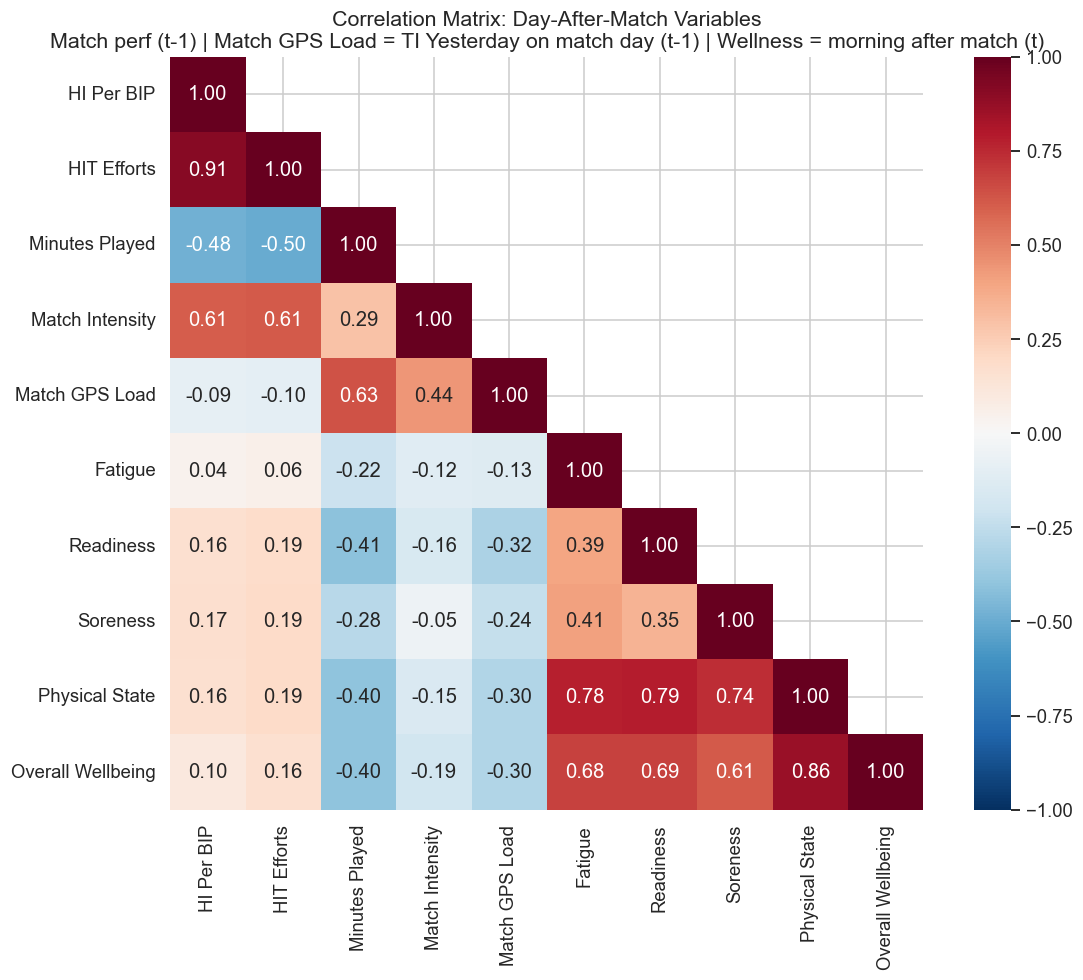

N = 154 rows (day after match with complete wellness data)
Note: Match GPS Load = Training Intensity Yesterday computed from match-day GPS %, not from a training session.


In [18]:
# Match performance correlation matrix
#
# TEMPORAL STRUCTURE of these rows (day after a match):
#   Match perf cols (t-1): player's performance in yesterday's match
#   Training Intensity Yesterday (t-1): GPS load from yesterday = the MATCH session
#   Wellness cols (morning t): how the player feels the morning after the match
#
# NOTE: 'Training Intensity Yesterday' on these rows does NOT reflect a
# training session -- it reflects the GPS load accumulated during the match.

match_corr_cols = match_cols + ['Training Intensity Yesterday', 'Fatigue (z)', 'Readiness (z)',
                                'Soreness (z)', 'Physical State', 'Overall Wellbeing']
match_corr_data = df[match_corr_cols].dropna()

rename_map = {
    'Match HID Per BIP Yesterday': 'HI Per BIP',
    'Match HIE Per BIP Yesterday': 'HIT Efforts',
    'Match Minutes Played Yesterday': 'Minutes Played',
    'Match Intensity Yesterday': 'Match Intensity',
    'Training Intensity Yesterday': 'Match GPS Load',
    'Fatigue (z)': 'Fatigue',
    'Readiness (z)': 'Readiness',
    'Soreness (z)': 'Soreness',
    'Physical State': 'Physical State',
    'Overall Wellbeing': 'Overall Wellbeing',
}
match_corr_data = match_corr_data.rename(columns=rename_map)

fig, ax = plt.subplots(figsize=(11, 9))
corr = match_corr_data.corr()
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            mask=mask, ax=ax, square=True)
ax.set_title('Correlation Matrix: Day-After-Match Variables\n'
             'Match perf (t-1) | Match GPS Load = TI Yesterday on match day (t-1) | '
             'Wellness = morning after match (t)')
plt.tight_layout()
plt.show()

print(f'N = {len(match_corr_data)} rows (day after match with complete wellness data)')
print('Note: Match GPS Load = Training Intensity Yesterday computed from match-day GPS %,'
      ' not from a training session.')

## 6. NaN Analysis: Training Intensity

Training Intensity Yesterday is NaN for **1,600** rows (37.7%). This section investigates what characterises those rows.

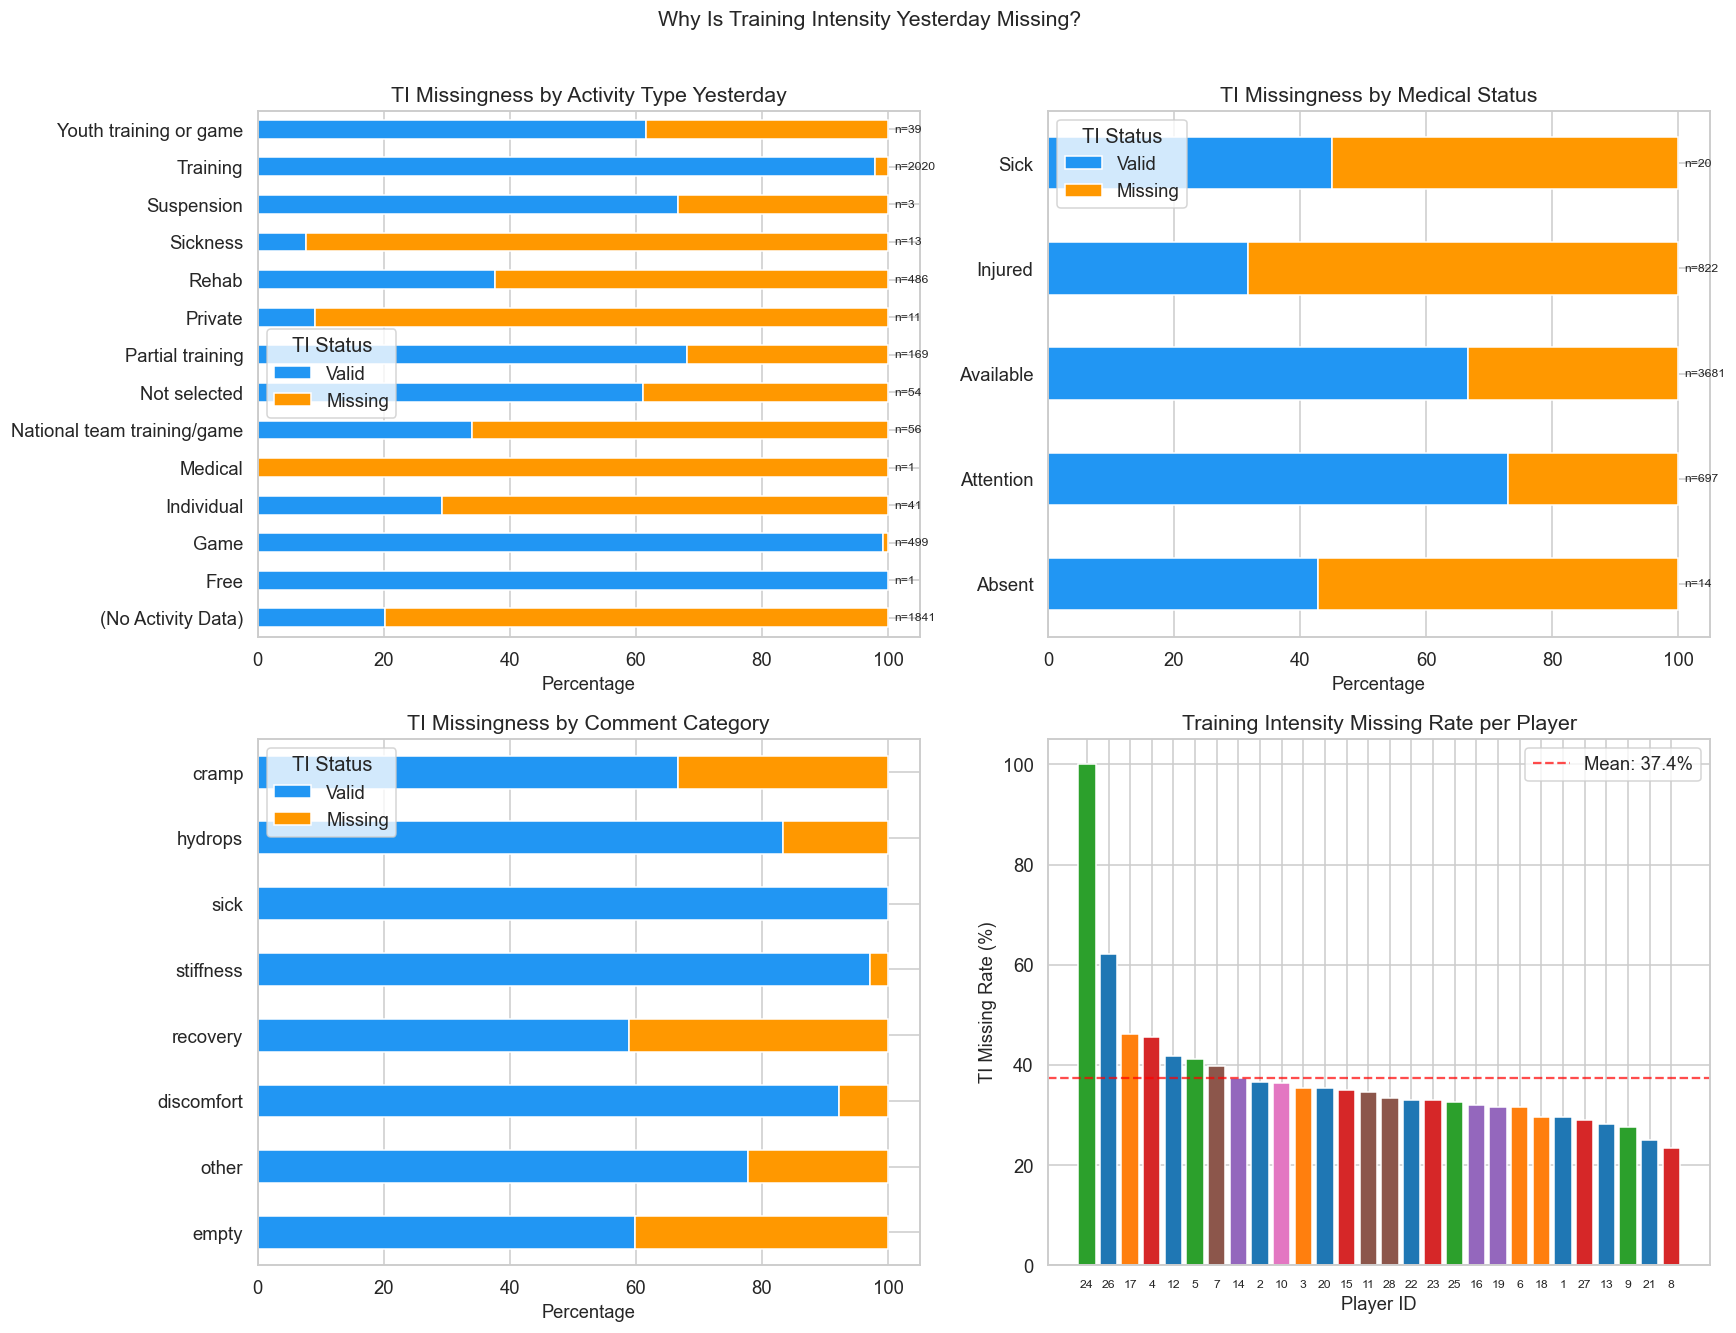

In [19]:
# Compare NaN vs valid rows
df_ti = df.copy()
df_ti['TI Status'] = df_ti['Training Intensity Yesterday'].apply(lambda x: 'Valid' if pd.notna(x) else 'Missing')

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Activity Type Yesterday breakdown
ax = axes[0, 0]
ct = pd.crosstab(df_ti['Activity Type Yesterday'].fillna('(No Activity Data)'), df_ti['TI Status'])
ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100
ct_pct[['Valid', 'Missing']].plot.barh(stacked=True, ax=ax, color=['#2196F3', '#FF9800'], edgecolor='white')
ax.set_title('TI Missingness by Activity Type Yesterday')
ax.set_xlabel('Percentage')
ax.set_ylabel('')
ax.legend(title='TI Status')
# Add count annotations
for i, (idx_name, row) in enumerate(ct.iterrows()):
    total = row.sum()
    ax.text(101, i, f'n={total}', va='center', fontsize=8)

# Status breakdown
ax = axes[0, 1]
ct2 = pd.crosstab(df_ti['Status'], df_ti['TI Status'])
ct2_pct = ct2.div(ct2.sum(axis=1), axis=0) * 100
ct2_pct[['Valid', 'Missing']].plot.barh(stacked=True, ax=ax, color=['#2196F3', '#FF9800'], edgecolor='white')
ax.set_title('TI Missingness by Medical Status')
ax.set_xlabel('Percentage')
ax.set_ylabel('')
ax.legend(title='TI Status')
for i, (idx_name, row) in enumerate(ct2.iterrows()):
    total = row.sum()
    ax.text(101, i, f'n={total}', va='center', fontsize=8)

# Comment Category breakdown
ax = axes[1, 0]
ct3 = pd.crosstab(df_ti['Comment Category Yesterday'], df_ti['TI Status'])
ct3_top = ct3.loc[ct3.sum(axis=1).sort_values(ascending=False).head(8).index]
ct3_pct = ct3_top.div(ct3_top.sum(axis=1), axis=0) * 100
ct3_pct[['Valid', 'Missing']].plot.barh(stacked=True, ax=ax, color=['#2196F3', '#FF9800'], edgecolor='white')
ax.set_title('TI Missingness by Comment Category')
ax.set_xlabel('Percentage')
ax.set_ylabel('')
ax.legend(title='TI Status')

# Per-player missingness rate
ax = axes[1, 1]
player_miss = df_ti.groupby('Player ID')['TI Status'].apply(lambda x: (x == 'Missing').mean() * 100).sort_values(ascending=False)
player_pos = df.drop_duplicates('Player ID').set_index('Player ID')['Position']
bar_colors = [POS_PALETTE.get(player_pos.get(p, ''), '#999') for p in player_miss.index]
ax.bar(range(len(player_miss)), player_miss.values, color=bar_colors, edgecolor='white')
ax.set_xticks(range(len(player_miss)))
ax.set_xticklabels([str(p) for p in player_miss.index], fontsize=8)
ax.set_xlabel('Player ID')
ax.set_ylabel('TI Missing Rate (%)')
ax.set_title('Training Intensity Missing Rate per Player')
ax.axhline(y=player_miss.mean(), color='red', linestyle='--', alpha=0.7, label=f'Mean: {player_miss.mean():.1f}%')
ax.legend()

plt.suptitle('Why Is Training Intensity Yesterday Missing?', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

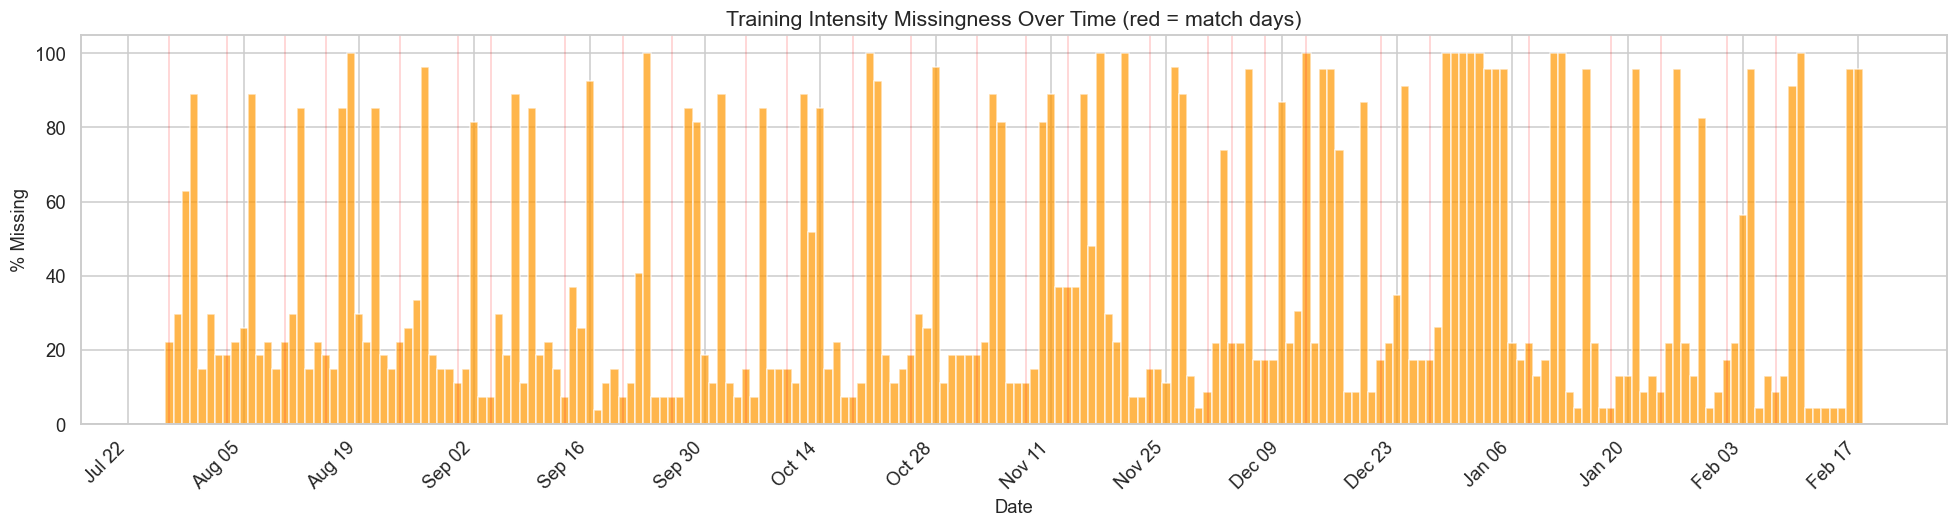

In [20]:
# NaN temporal pattern
daily_miss = df.groupby('Date')['Training Intensity Yesterday'].apply(lambda x: x.isna().mean() * 100)

fig, ax = plt.subplots(figsize=(18, 5))
ax.bar(daily_miss.index, daily_miss.values, color='#FF9800', alpha=0.7, width=1)
for md in match_dates:
    ax.axvline(md, color='red', alpha=0.2, linewidth=1)
ax.set_ylabel('% Missing')
ax.set_xlabel('Date')
ax.set_title('Training Intensity Missingness Over Time (red = match days)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
plt.xticks(rotation=45, ha='right')
ax.set_ylim(0, 105)
plt.tight_layout()
plt.show()

## 7. Wellness Z-Scores

Six individualised 28-day rolling-window z-scores from morning assessments.

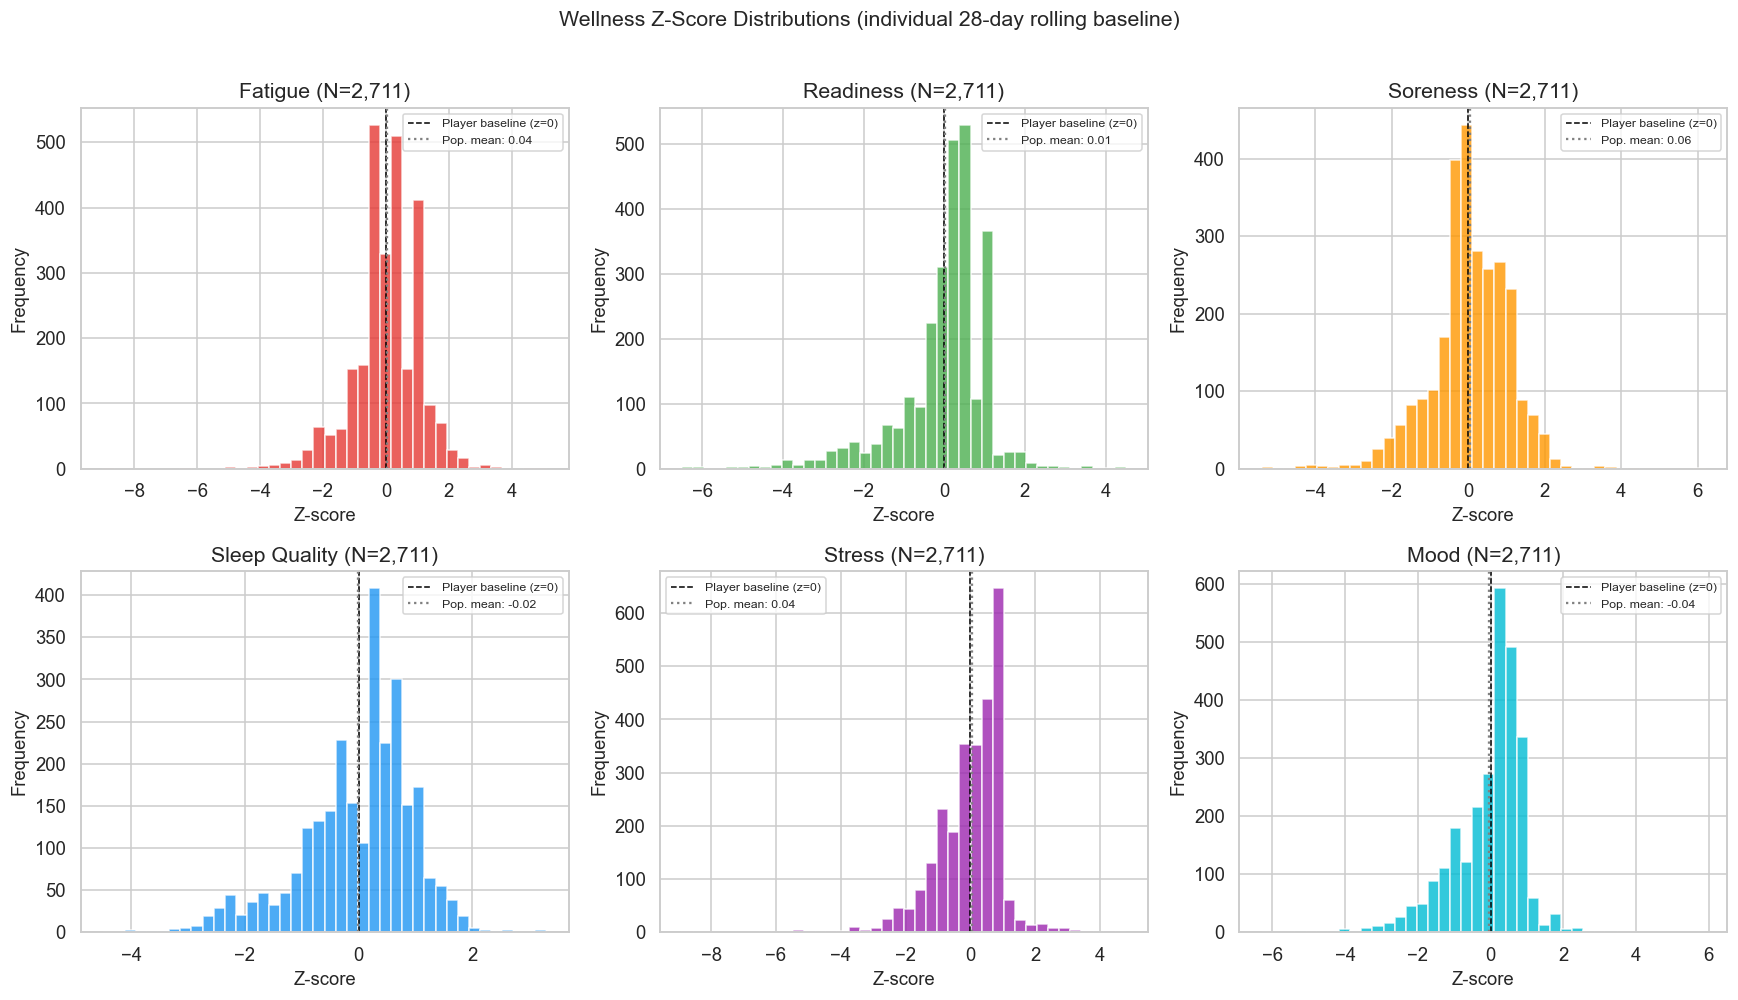

In [21]:
wellness_cols = ['Fatigue (z)', 'Readiness (z)', 'Soreness (z)',
                 'Sleep Quality (z)', 'Stress (z)', 'Mood (z)']
composite_cols = ['Physical State', 'Mental State', 'Overall Wellbeing']

# Distributions of all 6 z-scores
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
wellness_colors = ['#E53935', '#4CAF50', '#FF9800', '#2196F3', '#9C27B0', '#00BCD4']

for idx, (col, color) in enumerate(zip(wellness_cols, wellness_colors)):
    ax = axes[idx // 3, idx % 3]
    vals = df[col].dropna()
    ax.hist(vals, bins=40, color=color, edgecolor='white', alpha=0.8)
    ax.axvline(0, color='black', linestyle='--', linewidth=1, label='Player baseline (z=0)')
    ax.axvline(vals.mean(), color='grey', linestyle=':', linewidth=1.5, label=f'Pop. mean: {vals.mean():.2f}')
    short = col.replace(' (z)', '')
    ax.set_title(f'{short} (N={len(vals):,})')
    ax.set_xlabel('Z-score')
    ax.set_ylabel('Frequency')
    ax.legend(fontsize=8)

plt.suptitle('Wellness Z-Score Distributions (individual 28-day rolling baseline)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

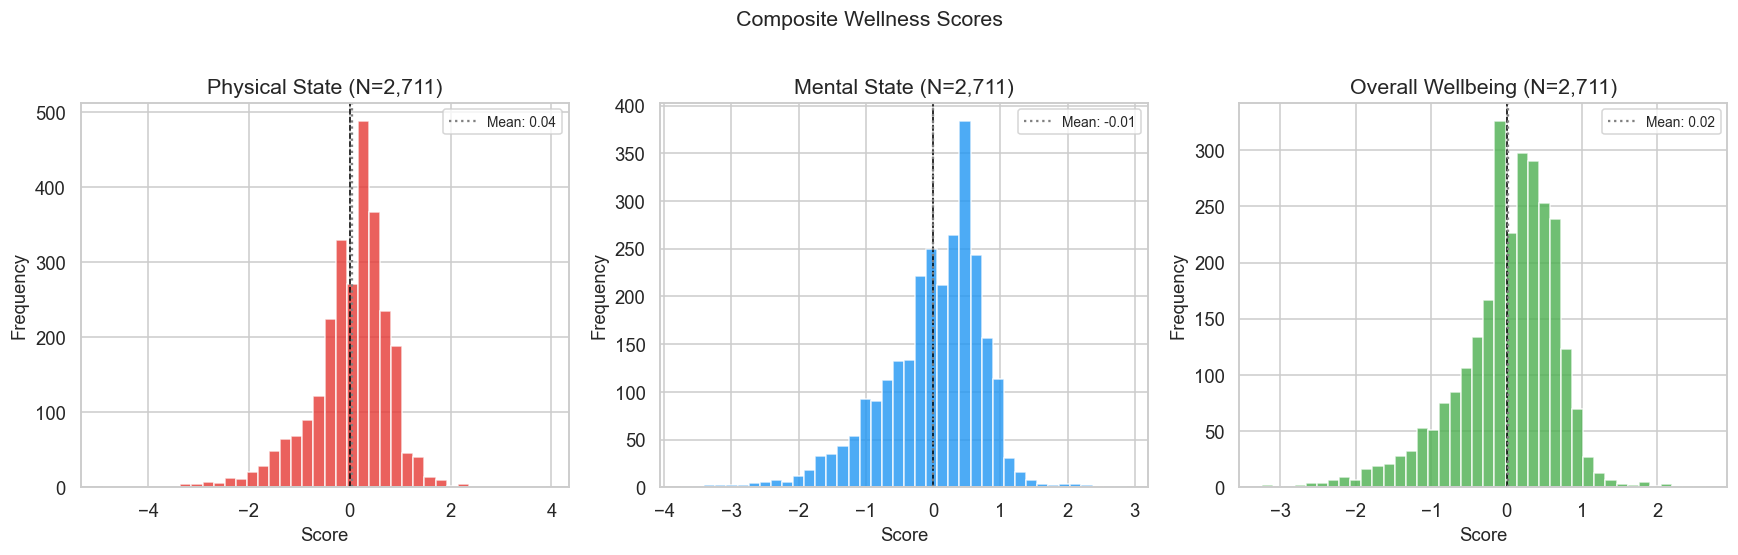

In [22]:
# Composite score distributions
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
comp_colors = ['#E53935', '#2196F3', '#4CAF50']

for idx, (col, color) in enumerate(zip(composite_cols, comp_colors)):
    ax = axes[idx]
    vals = df[col].dropna()
    ax.hist(vals, bins=40, color=color, edgecolor='white', alpha=0.8)
    ax.axvline(0, color='black', linestyle='--', linewidth=1)
    ax.axvline(vals.mean(), color='grey', linestyle=':', linewidth=1.5, label=f'Mean: {vals.mean():.2f}')
    ax.set_title(f'{col} (N={len(vals):,})')
    ax.set_xlabel('Score')
    ax.set_ylabel('Frequency')
    ax.legend(fontsize=9)

plt.suptitle('Composite Wellness Scores', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

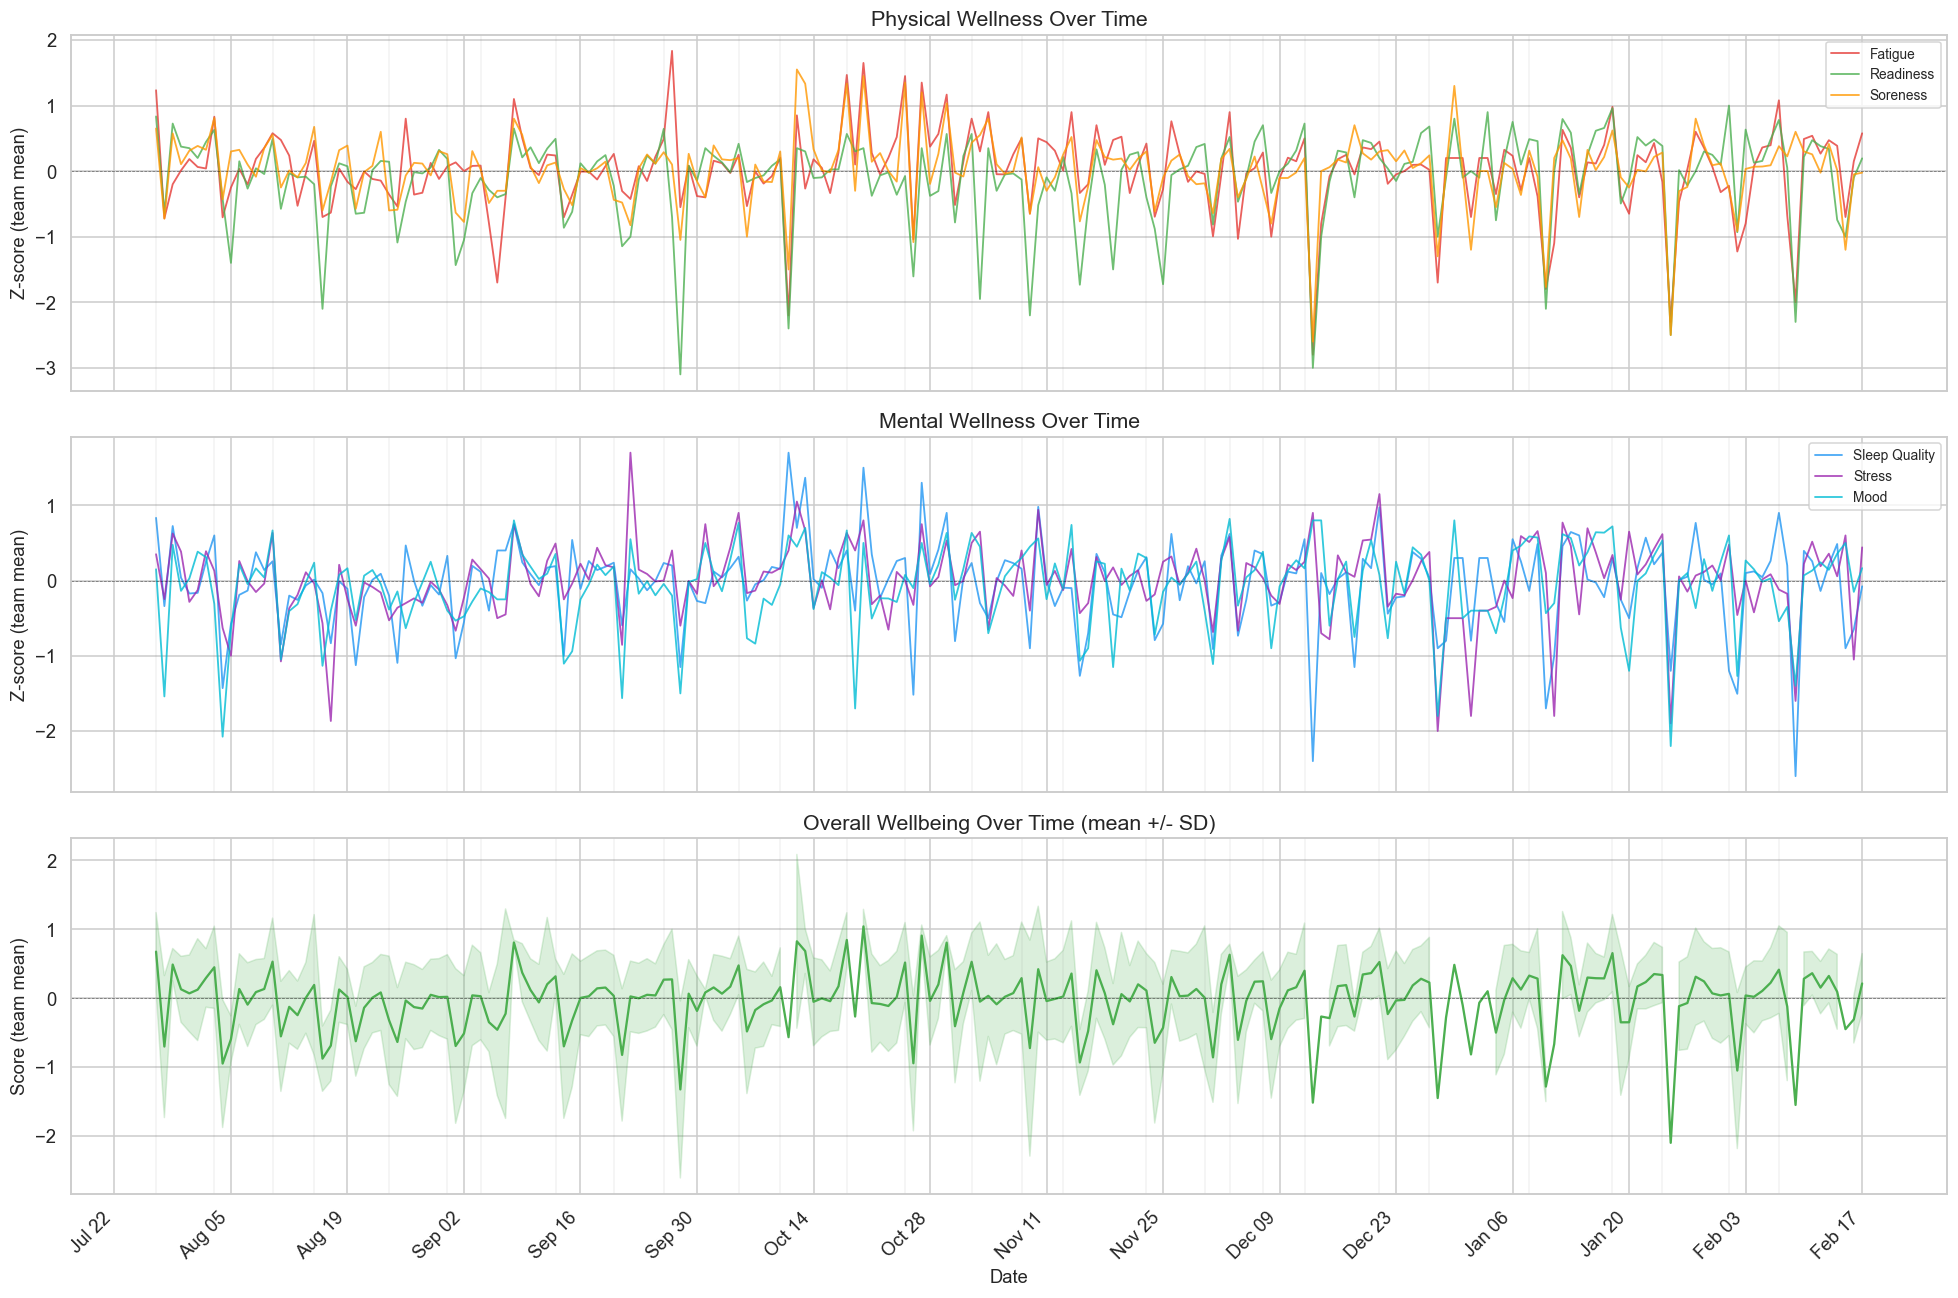

In [23]:
# Wellness z-scores over time (team average)
fig, axes = plt.subplots(3, 1, figsize=(18, 12), sharex=True)

# Physical wellness
ax = axes[0]
for col, color in zip(['Fatigue (z)', 'Readiness (z)', 'Soreness (z)'],
                       ['#E53935', '#4CAF50', '#FF9800']):
    daily = df.groupby('Date')[col].mean()
    ax.plot(daily.index, daily.values, color=color, linewidth=1.2, label=col.replace(' (z)', ''), alpha=0.8)
for md in match_dates:
    ax.axvline(md, color='grey', alpha=0.1, linewidth=1)
ax.axhline(0, color='black', linestyle='--', linewidth=0.5, alpha=0.5)
ax.set_ylabel('Z-score (team mean)')
ax.set_title('Physical Wellness Over Time')
ax.legend(loc='upper right', fontsize=9)

# Mental wellness
ax = axes[1]
for col, color in zip(['Sleep Quality (z)', 'Stress (z)', 'Mood (z)'],
                       ['#2196F3', '#9C27B0', '#00BCD4']):
    daily = df.groupby('Date')[col].mean()
    ax.plot(daily.index, daily.values, color=color, linewidth=1.2, label=col.replace(' (z)', ''), alpha=0.8)
for md in match_dates:
    ax.axvline(md, color='grey', alpha=0.1, linewidth=1)
ax.axhline(0, color='black', linestyle='--', linewidth=0.5, alpha=0.5)
ax.set_ylabel('Z-score (team mean)')
ax.set_title('Mental Wellness Over Time')
ax.legend(loc='upper right', fontsize=9)

# Overall wellbeing
ax = axes[2]
daily_ow = df.groupby('Date')['Overall Wellbeing'].agg(['mean', 'std'])
ax.plot(daily_ow.index, daily_ow['mean'], color='#4CAF50', linewidth=1.5)
ax.fill_between(daily_ow.index,
                daily_ow['mean'] - daily_ow['std'],
                daily_ow['mean'] + daily_ow['std'],
                alpha=0.2, color='#4CAF50')
for md in match_dates:
    ax.axvline(md, color='grey', alpha=0.1, linewidth=1)
ax.axhline(0, color='black', linestyle='--', linewidth=0.5, alpha=0.5)
ax.set_ylabel('Score (team mean)')
ax.set_title('Overall Wellbeing Over Time (mean +/- SD)')
ax.set_xlabel('Date')

for a in axes:
    a.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
    a.xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

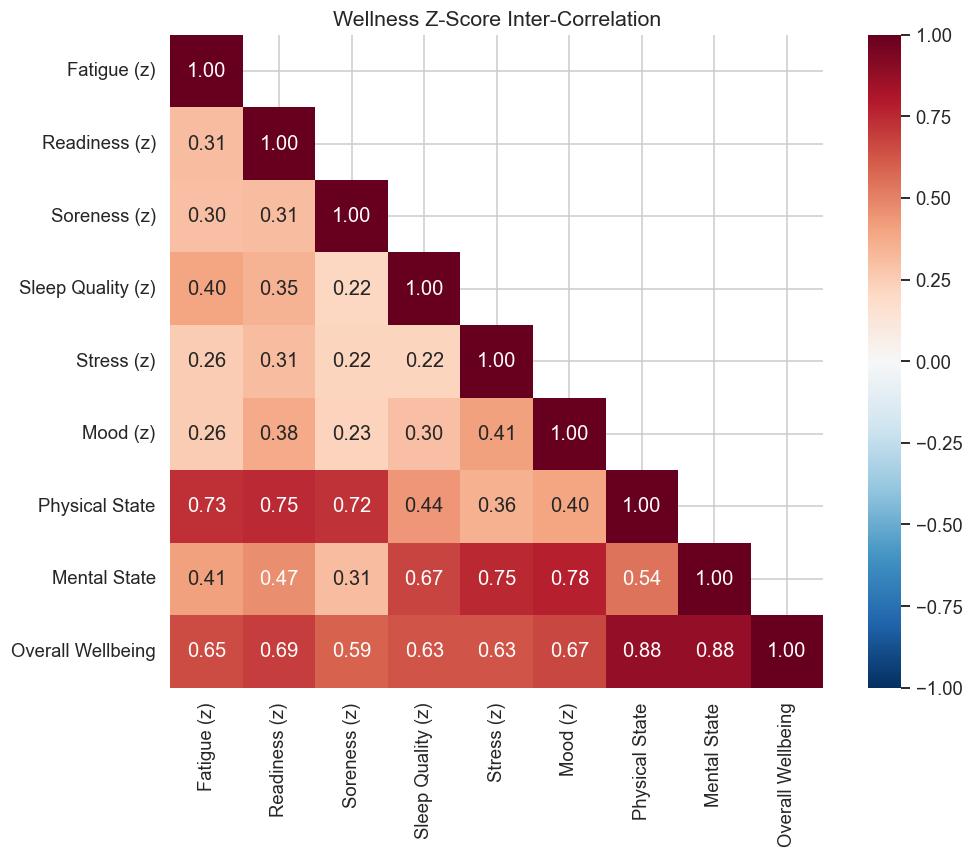

In [24]:
# Wellness z-score correlation heatmap
wellness_all = wellness_cols + composite_cols
fig, ax = plt.subplots(figsize=(10, 8))
corr_w = df[wellness_all].corr()
mask_w = np.triu(np.ones_like(corr_w, dtype=bool), k=1)
sns.heatmap(corr_w, annot=True, fmt='.2f', cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            mask=mask_w, ax=ax, square=True)
ax.set_title('Wellness Z-Score Inter-Correlation')
plt.tight_layout()
plt.show()

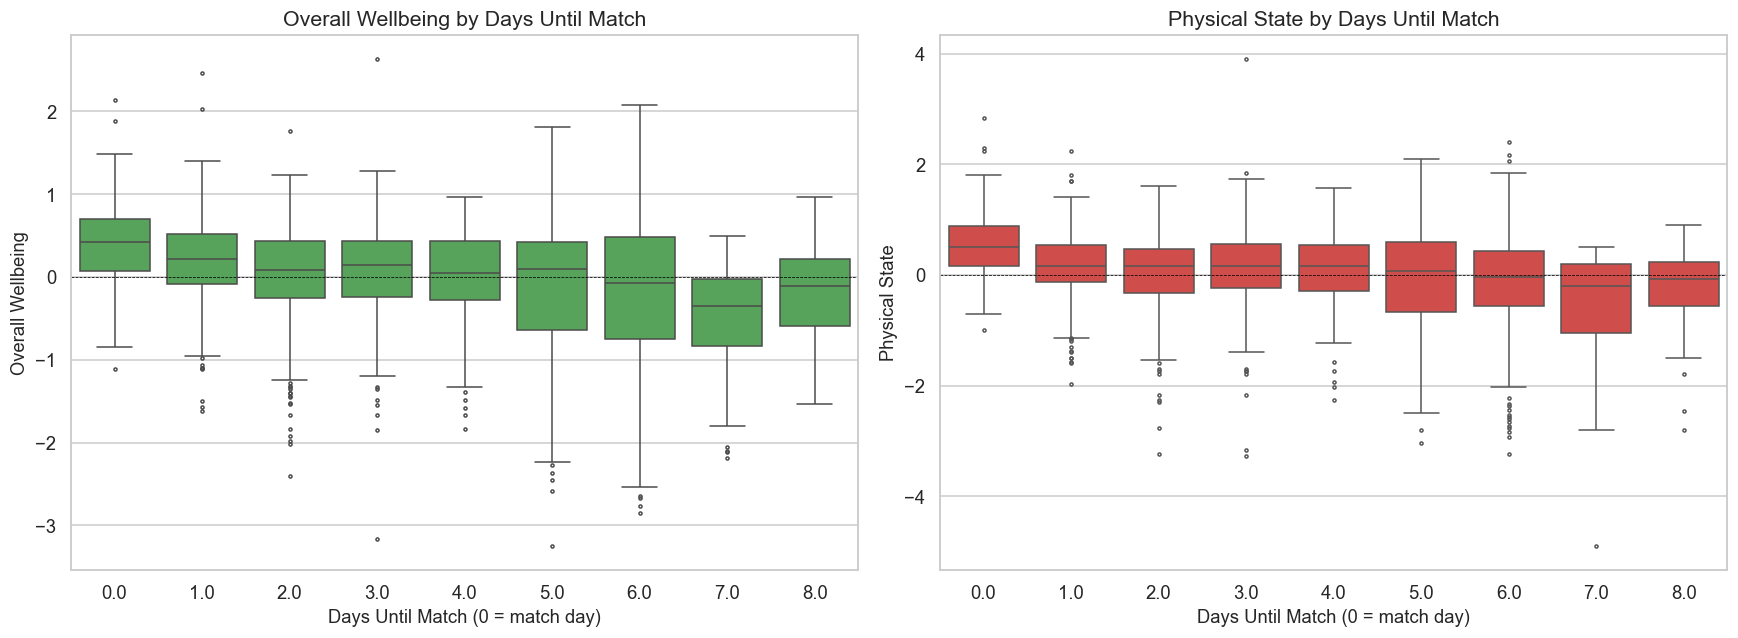

In [25]:
# Wellness by Days Until Match (does wellness vary through the match cycle?)
dum_wellness = df.dropna(subset=['Days Until Match', 'Overall Wellbeing'])
dum_wellness = dum_wellness[dum_wellness['Days Until Match'] <= 8]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Overall Wellbeing by DUM
ax = axes[0]
sns.boxplot(data=dum_wellness, x='Days Until Match', y='Overall Wellbeing',
            ax=ax, color='#4CAF50', fliersize=2)
ax.axhline(0, color='black', linestyle='--', linewidth=0.5)
ax.set_title('Overall Wellbeing by Days Until Match')
ax.set_xlabel('Days Until Match (0 = match day)')

# Physical State by DUM
ax = axes[1]
sns.boxplot(data=dum_wellness, x='Days Until Match', y='Physical State',
            ax=ax, color='#E53935', fliersize=2)
ax.axhline(0, color='black', linestyle='--', linewidth=0.5)
ax.set_title('Physical State by Days Until Match')
ax.set_xlabel('Days Until Match (0 = match day)')

plt.tight_layout()
plt.show()

## 8. ACWR & External Load

Acute:Chronic Workload Ratio (7:42 day exponentially weighted moving average). Danger zone: ACWR > 1.5.

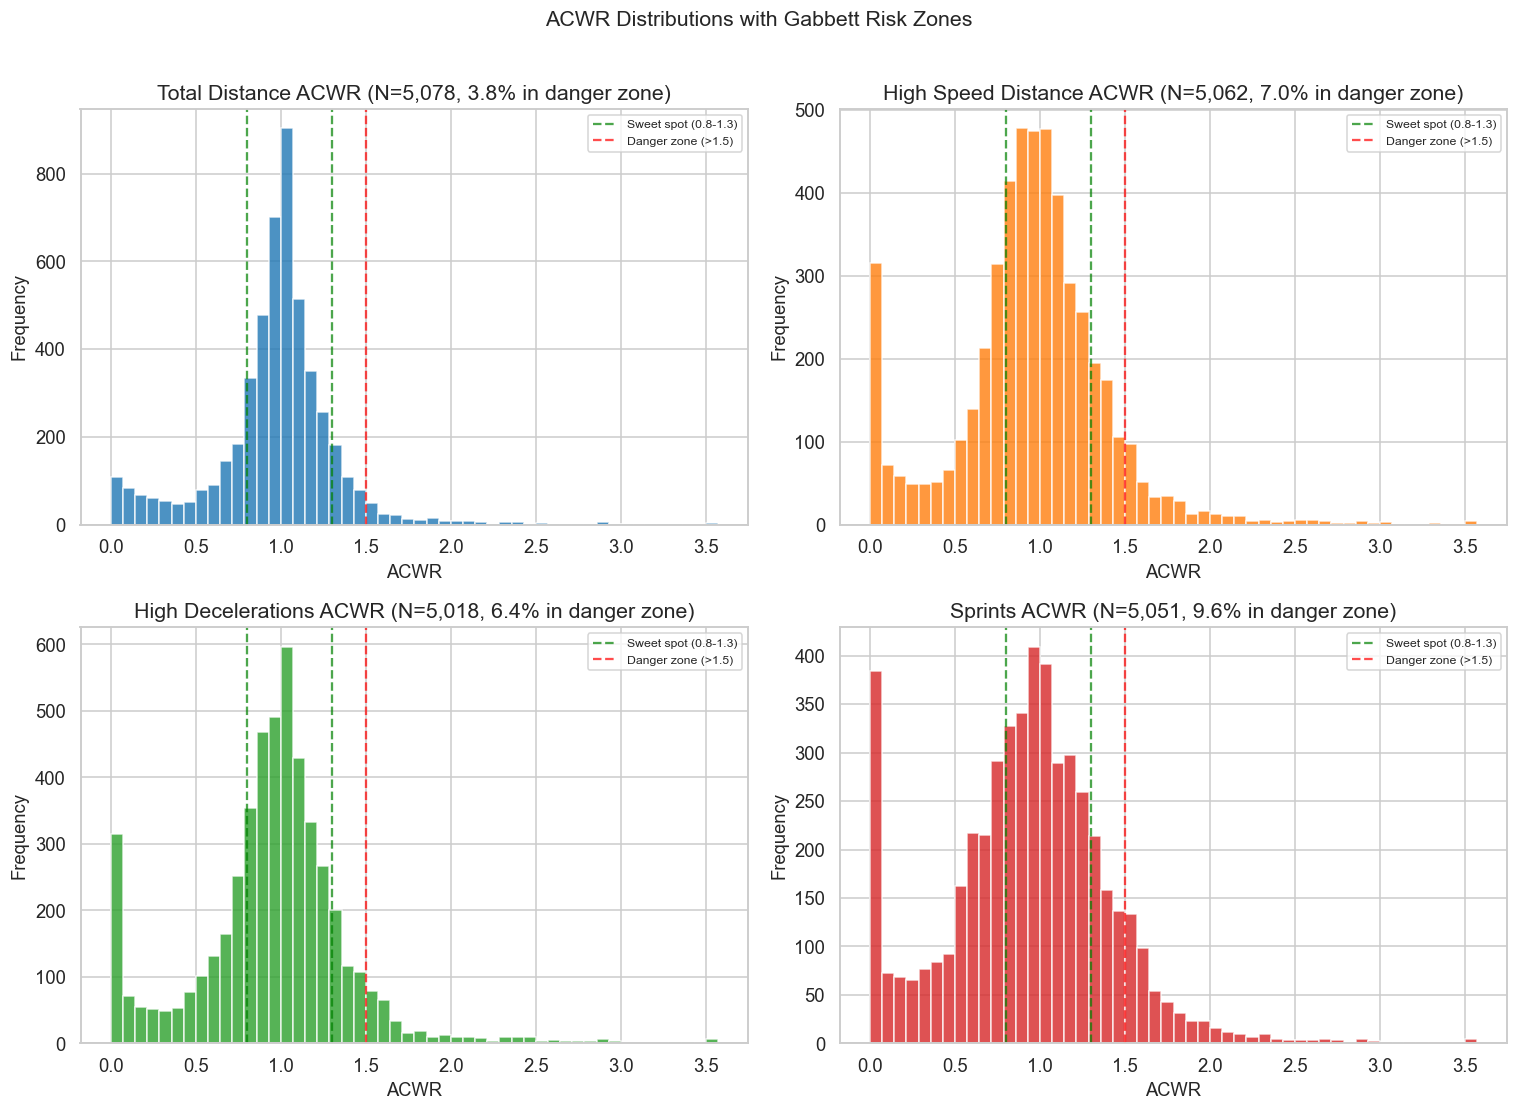

In [26]:
acwr_cols = ['Total Distance (ACWR) Yesterday', 'High Speed Distance (ACWR) Yesterday',
             'High Decelerations (ACWR) Yesterday', 'Sprints (ACWR) Yesterday']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
acwr_colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

for idx, (col, color) in enumerate(zip(acwr_cols, acwr_colors)):
    ax = axes[idx // 2, idx % 2]
    vals = df[col].dropna()
    ax.hist(vals, bins=50, color=color, edgecolor='white', alpha=0.8)
    # Gabbett zones
    ax.axvline(0.8, color='green', linestyle='--', linewidth=1.5, alpha=0.7, label='Sweet spot (0.8-1.3)')
    ax.axvline(1.3, color='green', linestyle='--', linewidth=1.5, alpha=0.7)
    ax.axvline(1.5, color='red', linestyle='--', linewidth=1.5, alpha=0.7, label='Danger zone (>1.5)')
    n_danger = (vals > 1.5).sum()
    pct_danger = 100 * n_danger / len(vals)
    short_name = col.replace(' (ACWR) Yesterday', '')
    ax.set_title(f'{short_name} ACWR (N={len(vals):,}, {pct_danger:.1f}% in danger zone)')
    ax.set_xlabel('ACWR')
    ax.set_ylabel('Frequency')
    ax.legend(fontsize=8)

plt.suptitle('ACWR Distributions with Gabbett Risk Zones', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

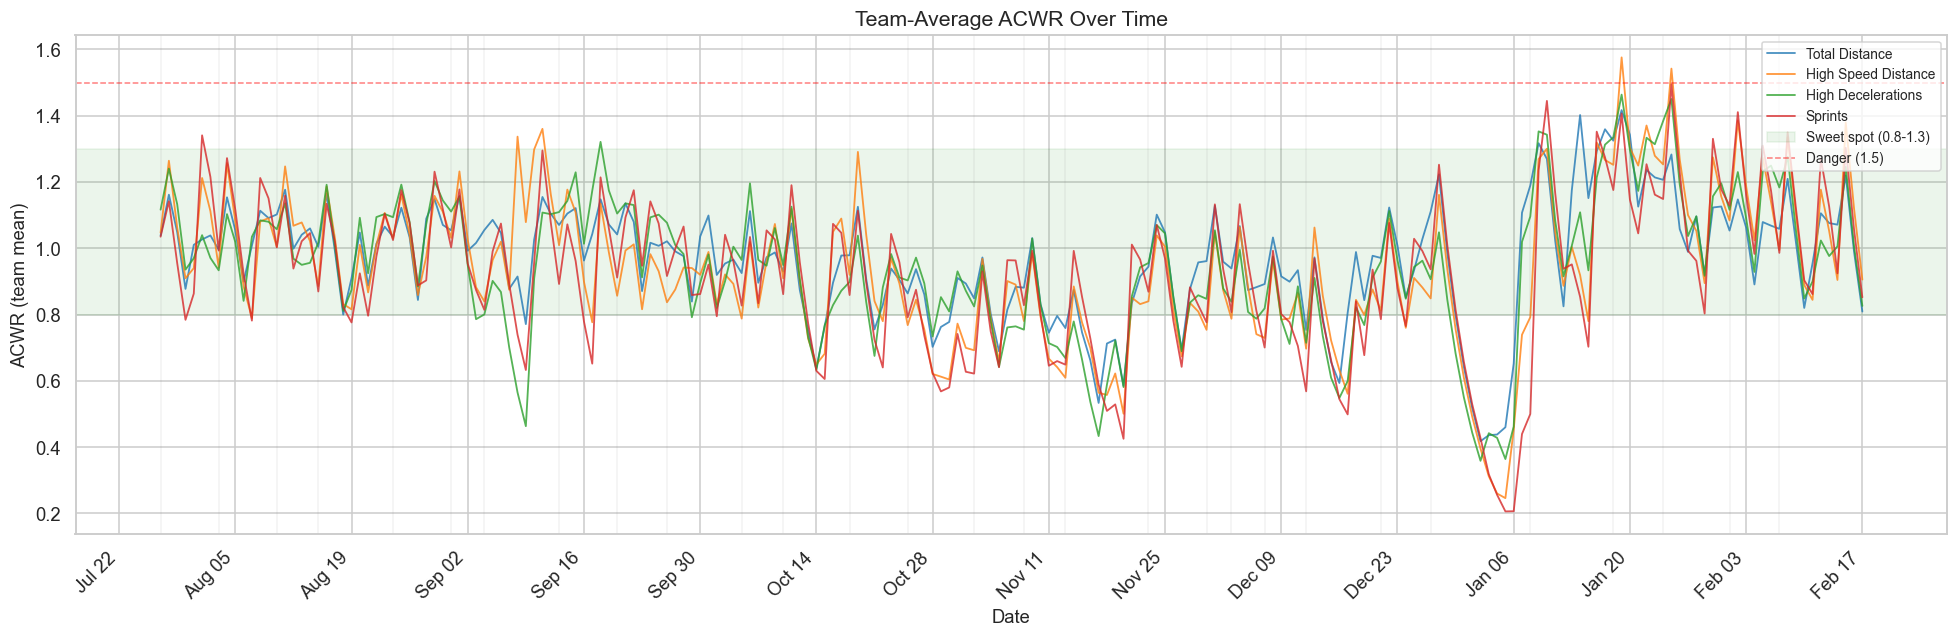

In [27]:
# ACWR over time (team average)
fig, ax = plt.subplots(figsize=(18, 6))

for col, color in zip(acwr_cols, acwr_colors):
    daily_acwr = df.groupby('Date')[col].mean()
    short_name = col.replace(' (ACWR) Yesterday', '')
    ax.plot(daily_acwr.index, daily_acwr.values, color=color, linewidth=1.2, label=short_name, alpha=0.8)

# Gabbett zones
ax.axhspan(0.8, 1.3, alpha=0.08, color='green', label='Sweet spot (0.8-1.3)')
ax.axhline(1.5, color='red', linestyle='--', linewidth=1, alpha=0.5, label='Danger (1.5)')

for md in match_dates:
    ax.axvline(md, color='grey', alpha=0.1, linewidth=1)

ax.set_xlabel('Date')
ax.set_ylabel('ACWR (team mean)')
ax.set_title('Team-Average ACWR Over Time')
ax.legend(loc='upper right', fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

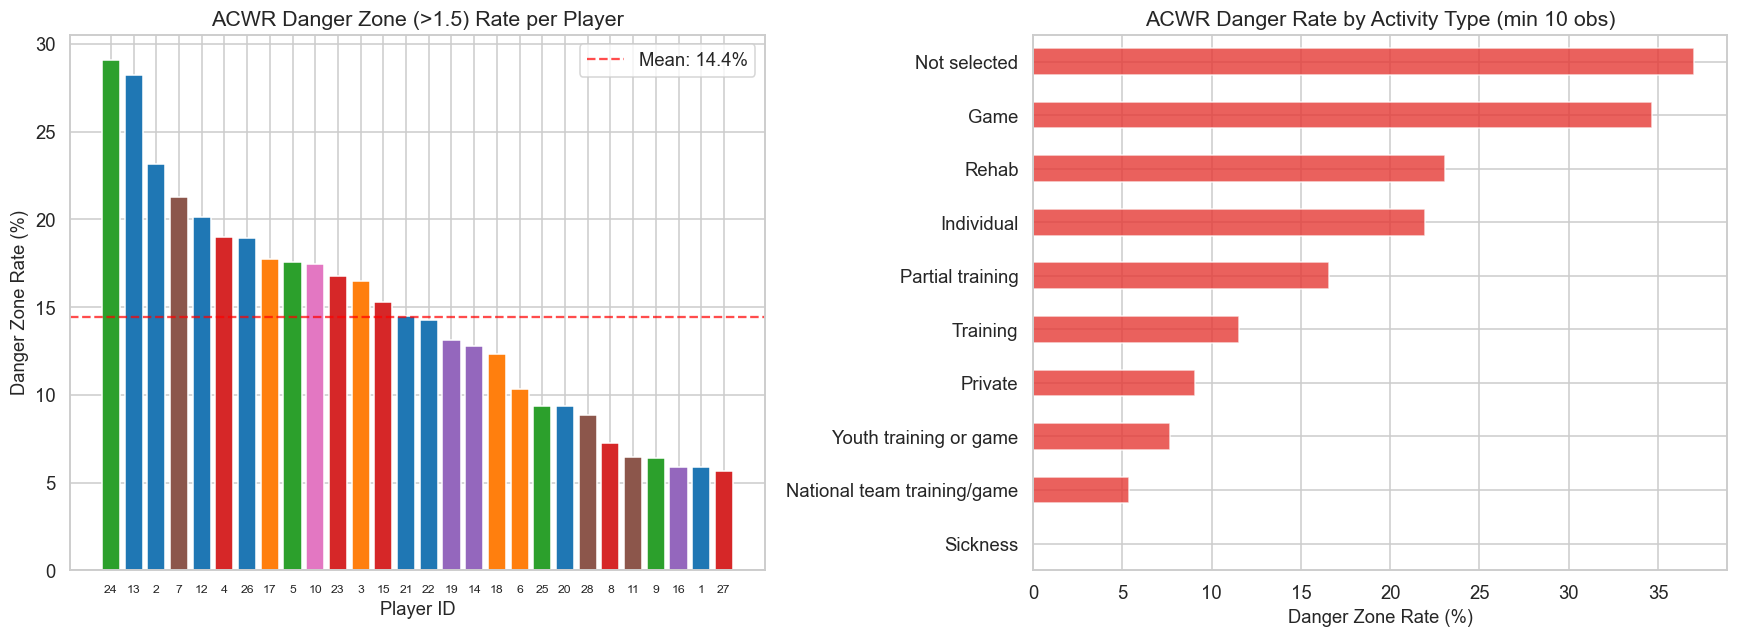

In [28]:
# ACWR danger flag analysis
danger_data = df.dropna(subset=['Any ACWR Danger'])
danger_rate = danger_data.groupby('Player ID')['Any ACWR Danger'].mean() * 100
danger_rate = danger_rate.sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Per-player danger rate
ax = axes[0]
player_pos = df.drop_duplicates('Player ID').set_index('Player ID')['Position']
bar_colors = [POS_PALETTE.get(player_pos.get(p, ''), '#999') for p in danger_rate.index]
ax.bar(range(len(danger_rate)), danger_rate.values, color=bar_colors, edgecolor='white')
ax.set_xticks(range(len(danger_rate)))
ax.set_xticklabels([str(p) for p in danger_rate.index], fontsize=8)
ax.set_xlabel('Player ID')
ax.set_ylabel('Danger Zone Rate (%)')
ax.set_title('ACWR Danger Zone (>1.5) Rate per Player')
ax.axhline(danger_rate.mean(), color='red', linestyle='--', alpha=0.7, label=f'Mean: {danger_rate.mean():.1f}%')
ax.legend()

# Danger rate by activity type
ax = axes[1]
danger_by_act = danger_data.dropna(subset=['Activity Type Yesterday']).groupby('Activity Type Yesterday')['Any ACWR Danger'].agg(['mean', 'count'])
danger_by_act = danger_by_act[danger_by_act['count'] >= 10]
danger_by_act = danger_by_act.sort_values('mean', ascending=True)
danger_by_act['mean_pct'] = danger_by_act['mean'] * 100
danger_by_act['mean_pct'].plot.barh(ax=ax, color='#E53935', edgecolor='white', alpha=0.8)
ax.set_xlabel('Danger Zone Rate (%)')
ax.set_ylabel('')
ax.set_title('ACWR Danger Rate by Activity Type (min 10 obs)')

plt.tight_layout()
plt.show()

## 9. Temporal Context

Days Since Game, Days Until Match, and Match Day structure.

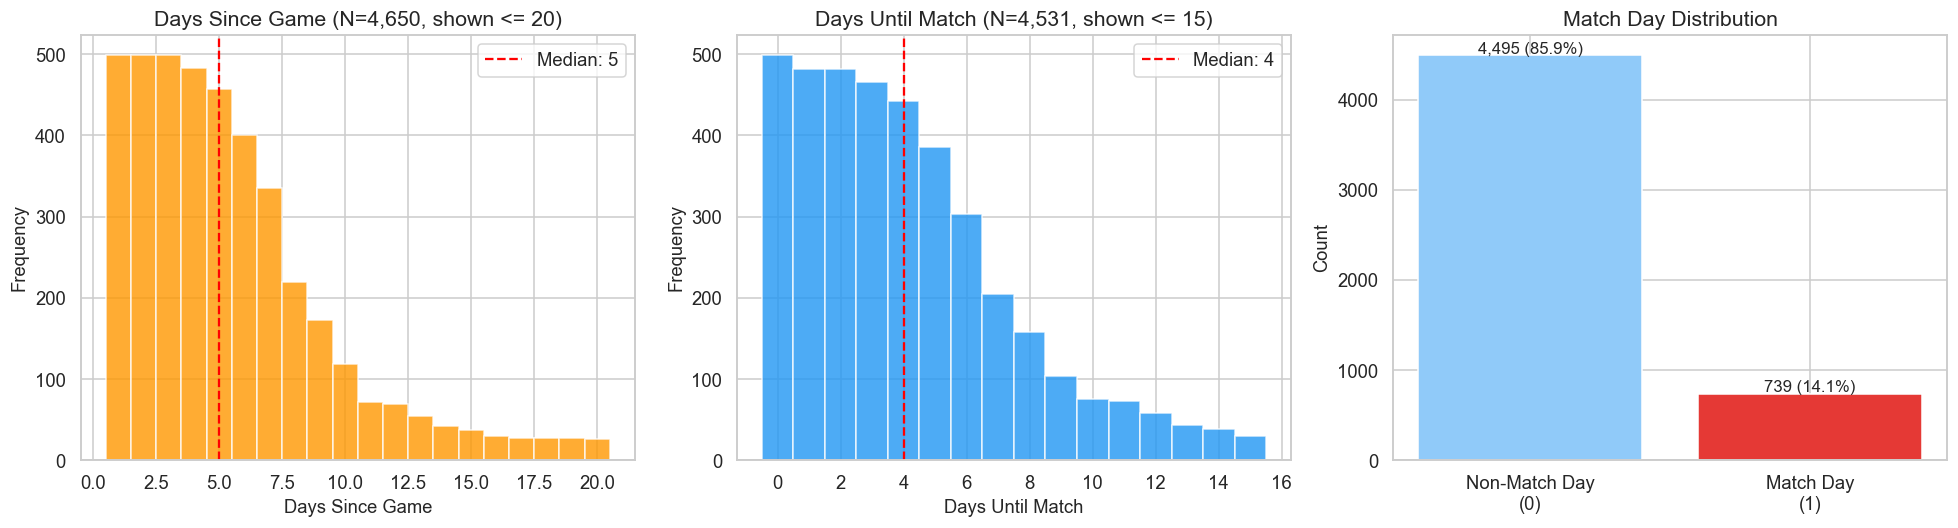

In [29]:
# Days Since Game & Days Until Match distributions
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Days Since Game
ax = axes[0]
dsg = df['Days Since Game'].dropna()
dsg_clipped = dsg[dsg <= 20]  # Focus on typical values
ax.hist(dsg_clipped, bins=range(1, 22), color='#FF9800', edgecolor='white', alpha=0.8, align='left')
ax.set_xlabel('Days Since Game')
ax.set_ylabel('Frequency')
ax.set_title(f'Days Since Game (N={len(dsg):,}, shown <= 20)')
ax.axvline(dsg.median(), color='red', linestyle='--', label=f'Median: {dsg.median():.0f}')
ax.legend()

# Days Until Match
ax = axes[1]
dum = df['Days Until Match'].dropna()
dum_clipped = dum[dum <= 15]
ax.hist(dum_clipped, bins=range(0, 17), color='#2196F3', edgecolor='white', alpha=0.8, align='left')
ax.set_xlabel('Days Until Match')
ax.set_ylabel('Frequency')
ax.set_title(f'Days Until Match (N={len(dum):,}, shown <= 15)')
ax.axvline(dum.median(), color='red', linestyle='--', label=f'Median: {dum.median():.0f}')
ax.legend()

# Match Day distribution
ax = axes[2]
md_counts = df['Match Day'].value_counts().sort_index()
ax.bar(['Non-Match Day\n(0)', 'Match Day\n(1)'], md_counts.values,
       color=['#90CAF9', '#E53935'], edgecolor='white')
for i, v in enumerate(md_counts.values):
    ax.text(i, v + 20, f'{v:,} ({100*v/len(df):.1f}%)', ha='center', fontsize=11)
ax.set_ylabel('Count')
ax.set_title('Match Day Distribution')

plt.tight_layout()
plt.show()

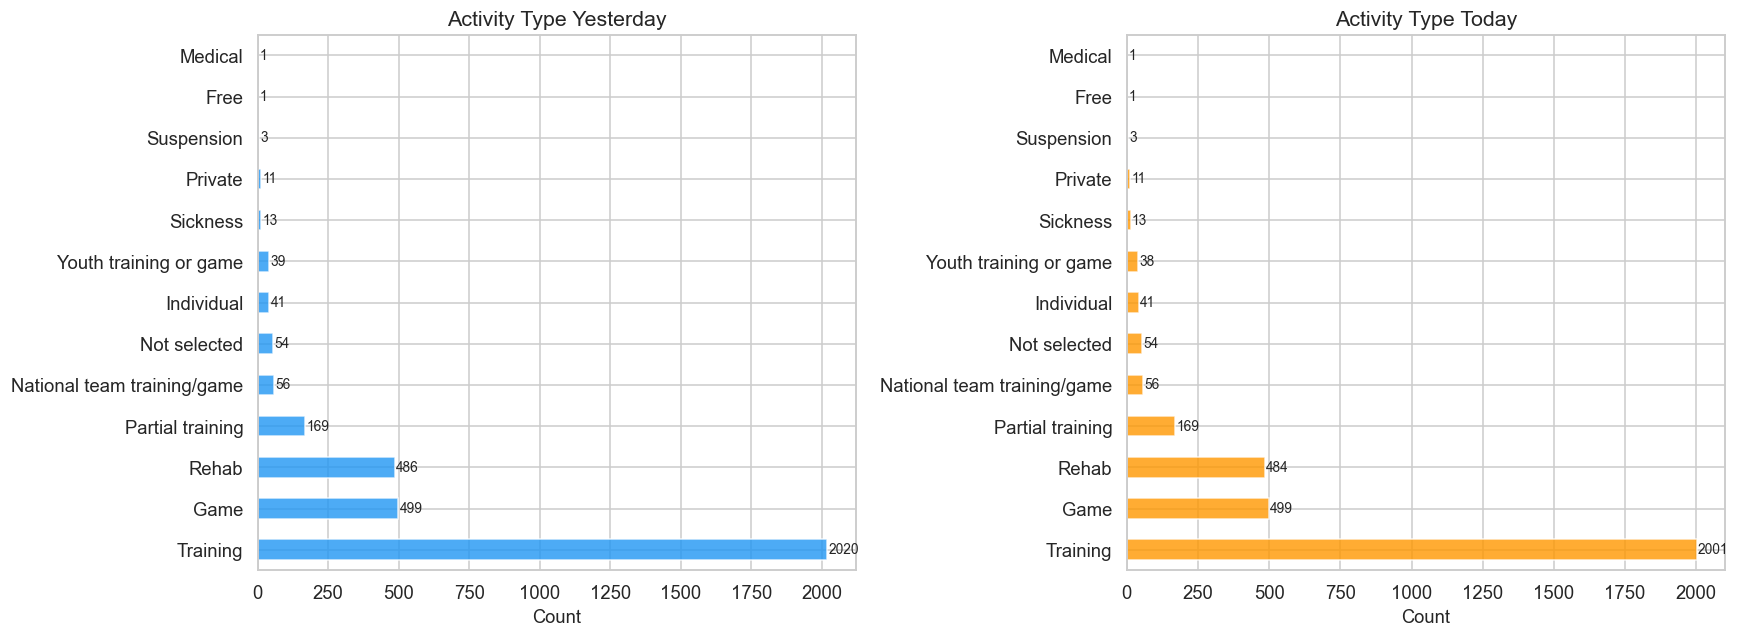

In [30]:
# Activity Type distribution
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Yesterday
ax = axes[0]
act_y = df['Activity Type Yesterday'].value_counts()
act_y.plot.barh(ax=ax, color='#2196F3', edgecolor='white', alpha=0.8)
ax.set_title('Activity Type Yesterday')
ax.set_xlabel('Count')
ax.set_ylabel('')
for i, v in enumerate(act_y.values):
    ax.text(v + 5, i, str(v), va='center', fontsize=9)

# Today
ax = axes[1]
act_t = df['Activity Type Today'].value_counts()
act_t.plot.barh(ax=ax, color='#FF9800', edgecolor='white', alpha=0.8)
ax.set_title('Activity Type Today')
ax.set_xlabel('Count')
ax.set_ylabel('')
for i, v in enumerate(act_t.values):
    ax.text(v + 5, i, str(v), va='center', fontsize=9)

plt.tight_layout()
plt.show()

## 10. Player Profiles

Per-player radar charts comparing average wellness, load, and match performance.

In [31]:
# Player-level summary statistics
profile_cols = {
    'Avg TI': 'Training Intensity Yesterday',
    'Avg Physical State': 'Physical State',
    'Avg Mental State': 'Mental State',
    'Avg Overall Wellbeing': 'Overall Wellbeing',
    'Avg ACWR (TD)': 'Total Distance (ACWR) Yesterday',
    'ACWR Danger %': 'Any ACWR Danger',
}

player_profiles = pd.DataFrame()
player_profiles['Position'] = df.groupby('Player ID')['Position'].first()
for label, col in profile_cols.items():
    if 'Danger' in label:
        player_profiles[label] = df.groupby('Player ID')[col].mean() * 100
    else:
        player_profiles[label] = df.groupby('Player ID')[col].mean()

# Add match stats for players with match data
for col, label in zip(match_cols, ['Avg HI Per BIP', 'Avg HIT Efforts', 'Avg Minutes Played', 'Avg Match Intensity']):
    player_profiles[label] = df.groupby('Player ID')[col].mean()

player_profiles['N Matches'] = df.groupby('Player ID')['Match HID Per BIP Yesterday'].apply(lambda x: x.notna().sum())
player_profiles['Status Decrease Rate %'] = df.groupby('Player ID')['Status Decrease'].mean() * 100

display(player_profiles.round(3).style.set_caption('Player Profiles Summary').background_gradient(cmap='RdYlGn', axis=0))

,Position,Avg TI,Avg Physical State,Avg Mental State,Avg Overall Wellbeing,Avg ACWR (TD),ACWR Danger %,Avg HI Per BIP,Avg HIT Efforts,Avg Minutes Played,Avg Match Intensity,N Matches,Status Decrease Rate %
Player ID,,,,,,,,,,,,,
1,CD,0.389000,-0.118000,-0.095000,-0.107000,0.989000,5.911000,13.344000,0.703000,96.355000,2.987000,25,0.971000
2,CD,0.373000,0.500000,0.004000,0.252000,0.975000,23.171000,nan,nan,nan,nan,0,0.000000
3,CAM,0.234000,-0.029000,0.179000,0.075000,0.912000,16.505000,14.110000,0.739000,79.549000,2.778000,16,2.427000
4,ST,0.343000,0.127000,0.076000,0.101000,1.139000,18.987000,17.159000,1.016000,73.263000,3.428000,16,2.913000
5,CDM,0.377000,0.105000,0.032000,0.068000,1.124000,17.544000,21.206000,1.194000,82.382000,4.600000,20,2.427000
6,CAM,0.343000,0.125000,0.098000,0.111000,0.980000,10.345000,19.937000,1.097000,58.573000,3.556000,22,4.369000
7,WG,0.607000,0.126000,0.381000,0.254000,0.984000,21.287000,24.961000,1.365000,58.501000,4.359000,11,2.427000
8,ST,0.432000,0.103000,-0.269000,-0.083000,0.980000,7.258000,27.080000,1.162000,13.547000,2.367000,6,0.000000
9,CDM,0.387000,0.055000,0.014000,0.035000,0.987000,6.404000,19.565000,1.096000,55.413000,3.307000,14,4.369000


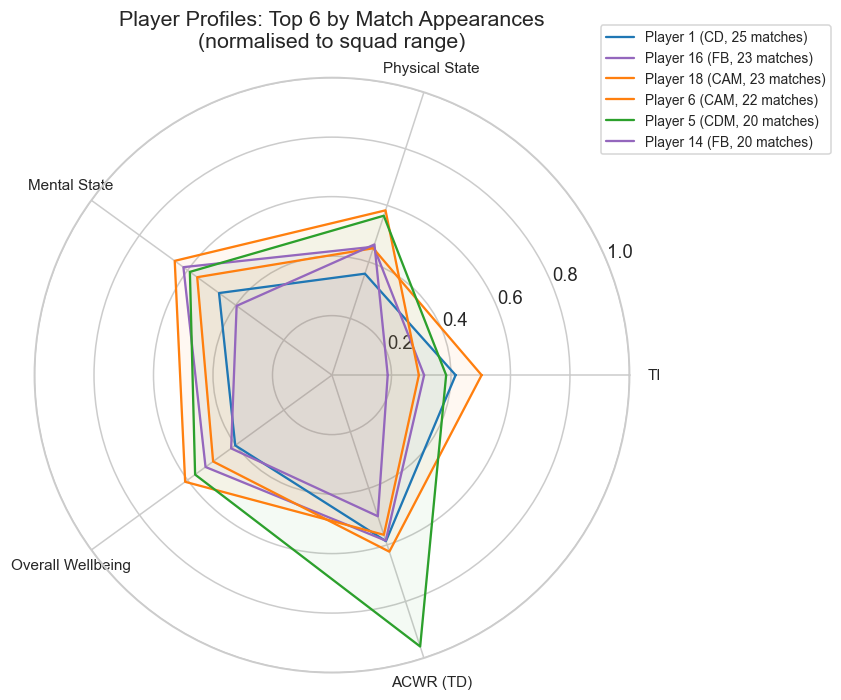

In [32]:
# Radar chart for selected players (top 6 by match appearances)
radar_metrics = ['Avg TI', 'Avg Physical State', 'Avg Mental State', 'Avg Overall Wellbeing', 'Avg ACWR (TD)']
top_match_players = player_profiles.nlargest(6, 'N Matches').index.tolist()

# Normalise each metric to [0, 1] for radar chart
radar_data = player_profiles.loc[top_match_players, radar_metrics].copy()
for col in radar_metrics:
    col_min = player_profiles[col].min()
    col_max = player_profiles[col].max()
    if col_max > col_min:
        radar_data[col] = (radar_data[col] - col_min) / (col_max - col_min)
    else:
        radar_data[col] = 0.5

angles = np.linspace(0, 2 * np.pi, len(radar_metrics), endpoint=False).tolist()
angles += angles[:1]  # Close the polygon

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

player_pos = df.drop_duplicates('Player ID').set_index('Player ID')['Position']
for pid in top_match_players:
    values = radar_data.loc[pid].tolist()
    values += values[:1]
    pos = player_pos.get(pid, '')
    color = POS_PALETTE.get(pos, '#999')
    n_matches = player_profiles.loc[pid, 'N Matches']
    ax.plot(angles, values, linewidth=1.5, label=f'Player {pid} ({pos}, {int(n_matches)} matches)', color=color)
    ax.fill(angles, values, alpha=0.05, color=color)

ax.set_xticks(angles[:-1])
ax.set_xticklabels([m.replace('Avg ', '') for m in radar_metrics], fontsize=10)
ax.set_ylim(0, 1)
ax.set_title('Player Profiles: Top 6 by Match Appearances\n(normalised to squad range)', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1), fontsize=9)

plt.tight_layout()
plt.show()

## 11. Correlation Analysis

How do all the key numerical variables relate to each other?

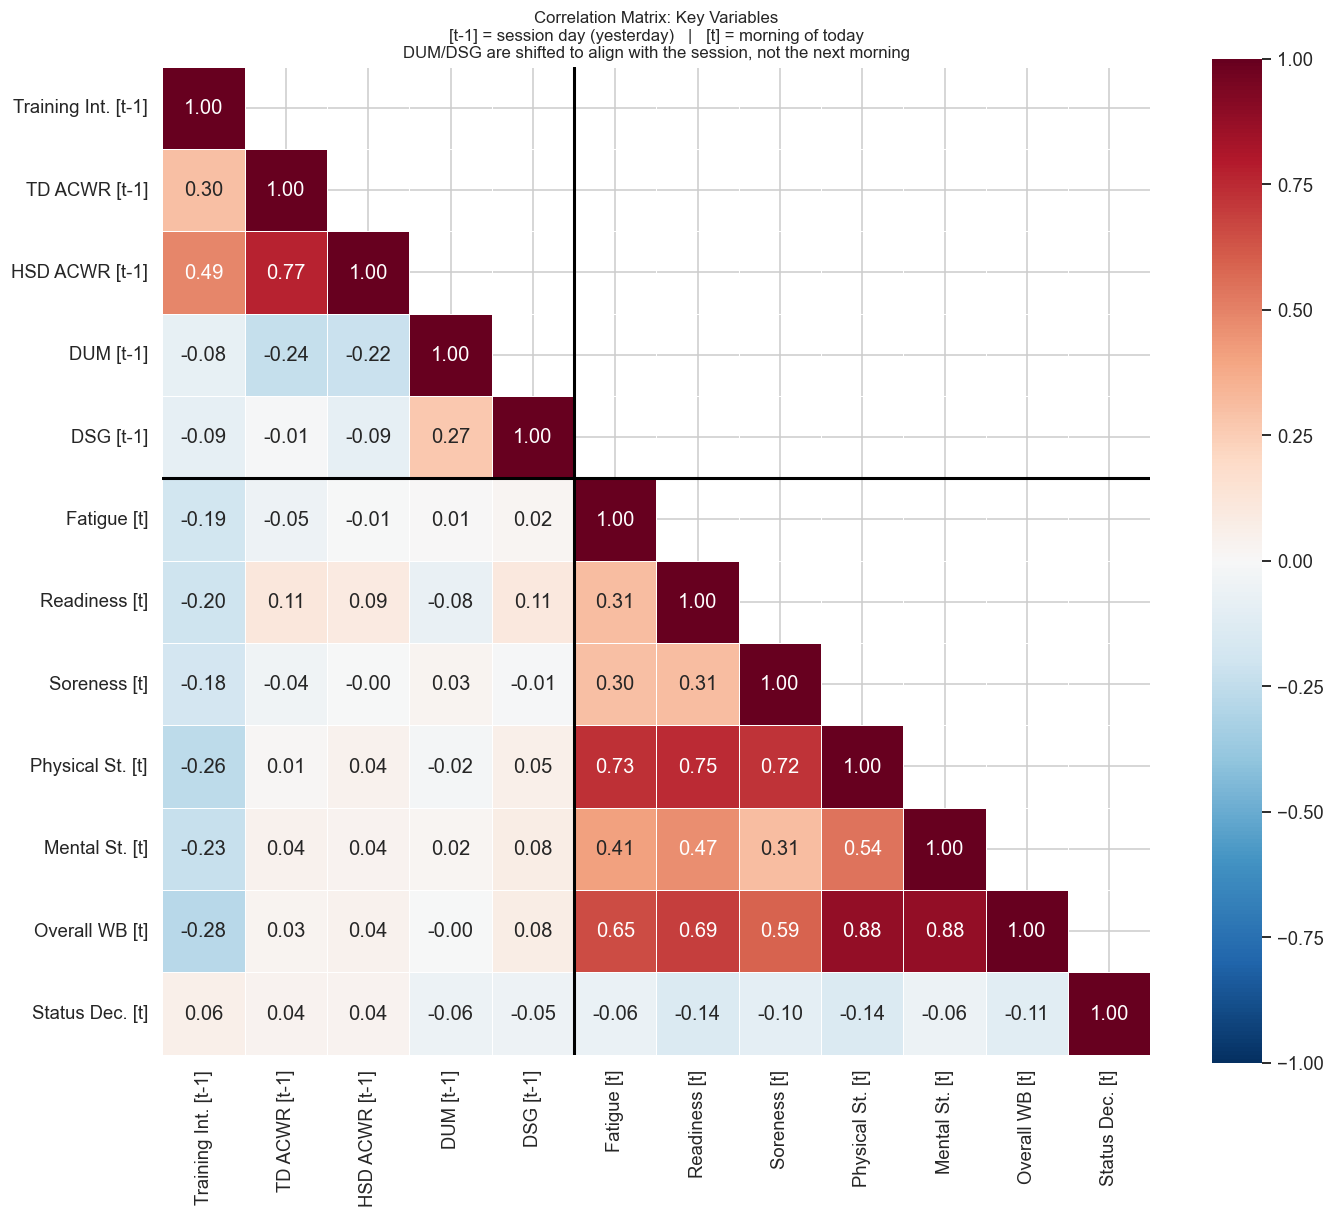

In [33]:
# Full correlation heatmap
#
# TEMPORAL GROUPS:
#   t-1 variables : Training Intensity Yesterday, ACWR columns
#   Morning of t  : Wellness z-scores, Status Decrease
#   Cycle position: DUM_session / DSG_session = DUM/DSG on the day the
#                   session occurred (shifted back 1 row per player),
#                   so they align temporally with TI Yesterday.
#
# TI Yesterday vs Wellness/Status Decrease = correct causal direction (t-1 -> t)
# TI Yesterday vs DUM_session/DSG_session  = same-day cycle context (t-1 vs t-1)

df_corr = df.sort_values(['Player ID', 'Date']).copy()
df_corr['DUM (session day)'] = df_corr.groupby('Player ID')['Days Until Match'].shift(1)
df_corr['DSG (session day)'] = df_corr.groupby('Player ID')['Days Since Game'].shift(1)

corr_cols = [
    'Training Intensity Yesterday',
    'Total Distance (ACWR) Yesterday',
    'High Speed Distance (ACWR) Yesterday',
    'DUM (session day)',
    'DSG (session day)',
    'Fatigue (z)', 'Readiness (z)', 'Soreness (z)',
    'Physical State', 'Mental State', 'Overall Wellbeing',
    'Status Decrease',
]

short_names = {
    'Training Intensity Yesterday': 'Training Int. [t-1]',
    'Total Distance (ACWR) Yesterday': 'TD ACWR [t-1]',
    'High Speed Distance (ACWR) Yesterday': 'HSD ACWR [t-1]',
    'DUM (session day)': 'DUM [t-1]',
    'DSG (session day)': 'DSG [t-1]',
    'Fatigue (z)': 'Fatigue [t]',
    'Readiness (z)': 'Readiness [t]',
    'Soreness (z)': 'Soreness [t]',
    'Physical State': 'Physical St. [t]',
    'Mental State': 'Mental St. [t]',
    'Overall Wellbeing': 'Overall WB [t]',
    'Status Decrease': 'Status Dec. [t]',
}

corr_data = df_corr[corr_cols].rename(columns=short_names)
corr_matrix = corr_data.corr()

fig, ax = plt.subplots(figsize=(13, 11))
mask_c = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, mask=mask_c, ax=ax, square=True, linewidths=0.5)
ax.set_title('Correlation Matrix: Key Variables\n'
             '[t-1] = session day (yesterday)   |   [t] = morning of today\n'
             'DUM/DSG are shifted to align with the session, not the next morning',
             fontsize=11)

# Draw a visual separator between the t-1 block and the t block
n_t1 = 5  # first 5 variables are t-1
ax.axhline(n_t1, color='black', linewidth=2)
ax.axvline(n_t1, color='black', linewidth=2)

plt.tight_layout()
plt.show()

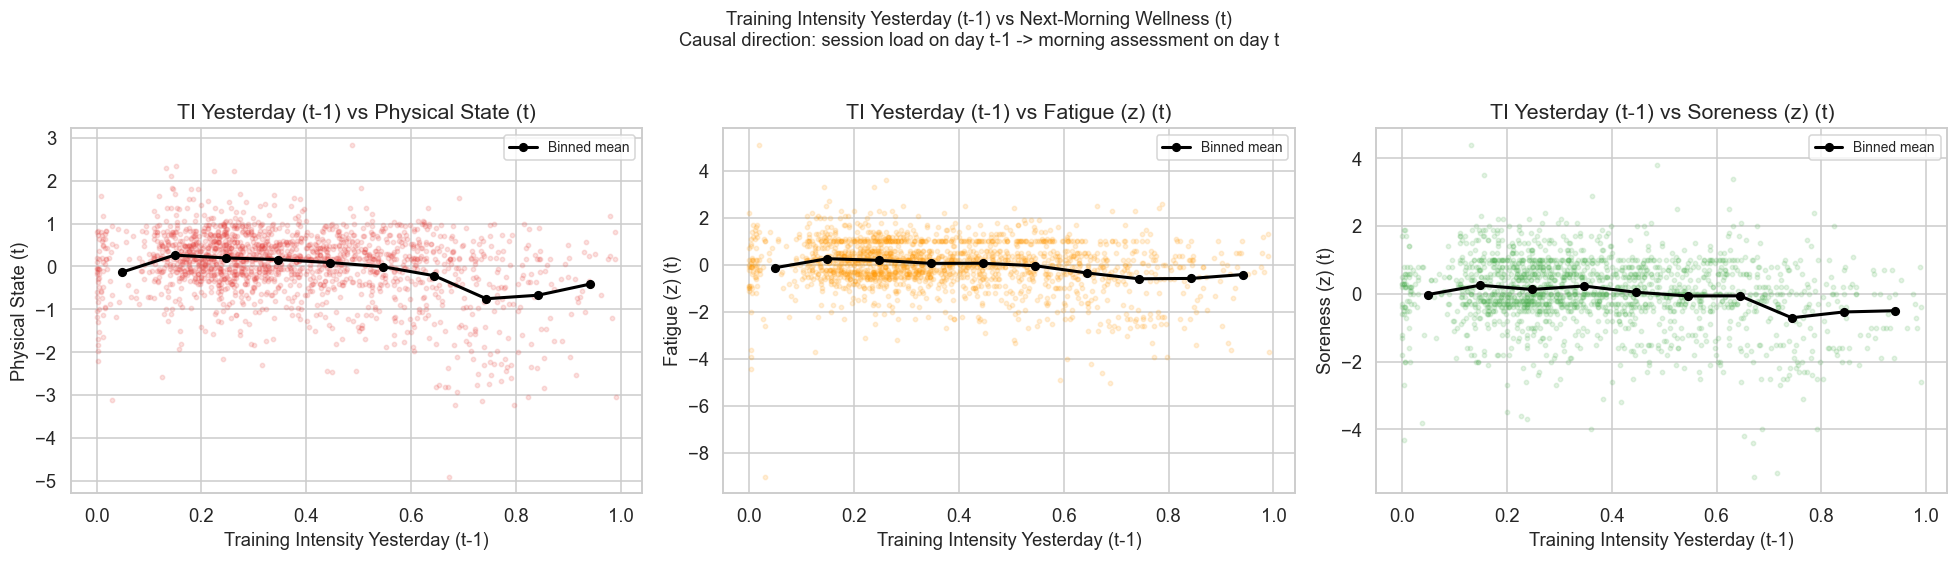

In [34]:
# Training Intensity Yesterday (t-1) vs Next-Morning Wellness (t)
#
# TEMPORAL STRUCTURE:
#   Training Intensity Yesterday = GPS load of the session on day t-1.
#   Fatigue (z), Soreness (z), Physical State = morning assessment of day t.
#   These are NOT same-day values.
#   The plot shows: how does yesterday's training load relate to
#   how the player feels the next morning?
#   Causal direction: session load (t-1) -> morning wellness (t).
#
# Note: the expected pattern is confounded -- coaches prescribe harder sessions
# when players are fresh (low fatigue, high readiness). The raw correlation
# may therefore be POSITIVE (high TI -> high fatigue) or near zero depending
# on which effect dominates.

scatter_data = df.dropna(subset=['Training Intensity Yesterday', 'Physical State'])

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (col, color, label) in enumerate([
    ('Physical State', '#E53935', 'Physical State (t)'),
    ('Fatigue (z)',    '#FF9800', 'Fatigue (z) (t)'),
    ('Soreness (z)',   '#4CAF50', 'Soreness (z) (t)'),
]):
    ax = axes[idx]
    valid = scatter_data.dropna(subset=[col])
    ax.scatter(valid['Training Intensity Yesterday'], valid[col],
               alpha=0.15, s=8, color=color)
    bins = pd.cut(valid['Training Intensity Yesterday'], bins=10)
    binned_mean = valid.groupby(bins, observed=True)[col].mean()
    bin_centers = [(b.left + b.right) / 2 for b in binned_mean.index]
    ax.plot(bin_centers, binned_mean.values,
            color='black', linewidth=2, marker='o', markersize=5, label='Binned mean')
    ax.set_xlabel('Training Intensity Yesterday (t-1)')
    ax.set_ylabel(label)
    ax.set_title(f'TI Yesterday (t-1) vs {label}')
    ax.legend(fontsize=9)

plt.suptitle('Training Intensity Yesterday (t-1) vs Next-Morning Wellness (t)\n'
             'Causal direction: session load on day t-1 -> morning assessment on day t',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

## 12. Status & Status Decrease

Medical status transitions: the binary target variable for standard ML experiments.

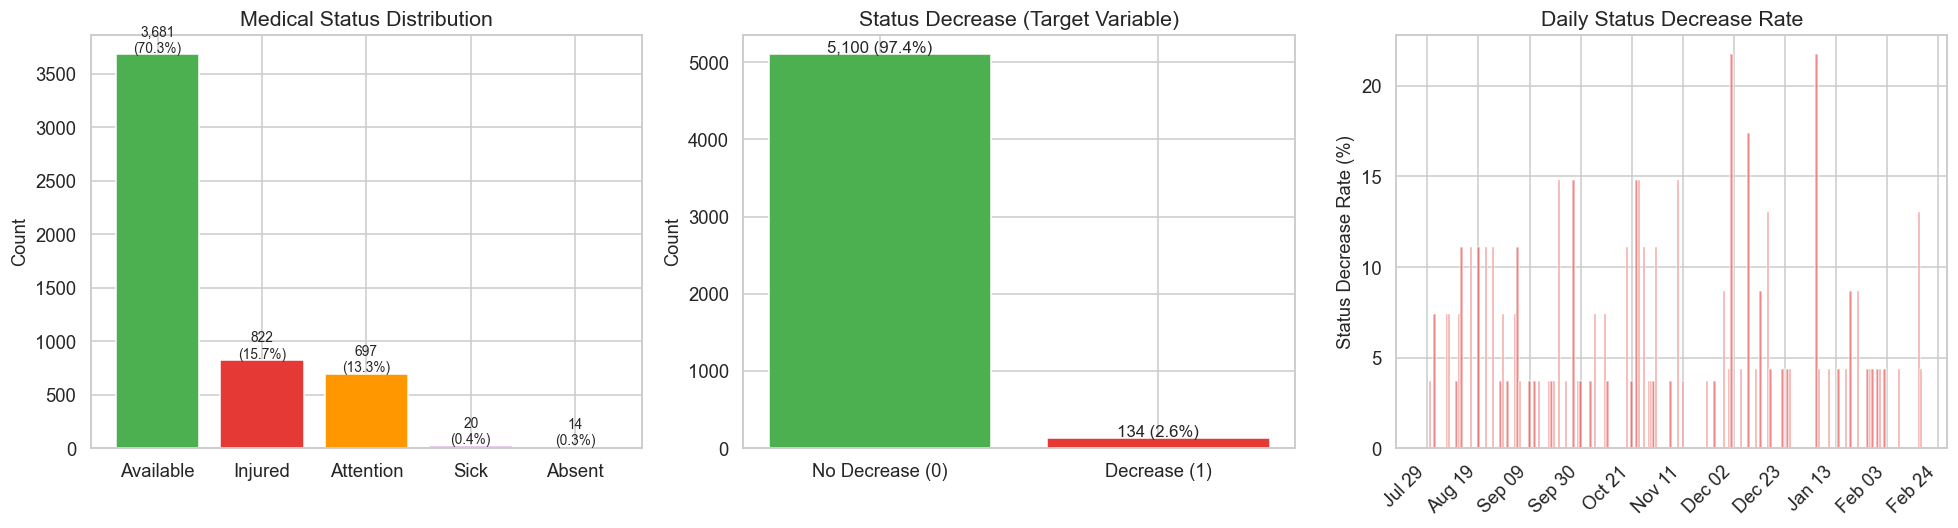

In [35]:
# Status distribution and Status Decrease rate
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Status counts
ax = axes[0]
status_counts = df['Status'].value_counts()
status_colors = {'Available': '#4CAF50', 'Attention': '#FF9800', 'Injured': '#E53935', 'Sick': '#9C27B0', 'Absent': '#757575'}
bars = ax.bar(status_counts.index, status_counts.values,
              color=[status_colors.get(s, '#999') for s in status_counts.index], edgecolor='white')
for i, v in enumerate(status_counts.values):
    ax.text(i, v + 20, f'{v:,}\n({100*v/len(df):.1f}%)', ha='center', fontsize=9)
ax.set_ylabel('Count')
ax.set_title('Medical Status Distribution')

# Status Decrease class balance
ax = axes[1]
sd_counts = df['Status Decrease'].value_counts().sort_index()
ax.bar(['No Decrease (0)', 'Decrease (1)'], sd_counts.values,
       color=['#4CAF50', '#E53935'], edgecolor='white')
for i, v in enumerate(sd_counts.values):
    ax.text(i, v + 20, f'{v:,} ({100*v/len(df):.1f}%)', ha='center', fontsize=11)
ax.set_ylabel('Count')
ax.set_title('Status Decrease (Target Variable)')

# Status Decrease rate over time
ax = axes[2]
daily_sd = df.groupby('Date')['Status Decrease'].mean() * 100
ax.bar(daily_sd.index, daily_sd.values, color='#E53935', alpha=0.6, width=1)
ax.set_ylabel('Status Decrease Rate (%)')
ax.set_title('Daily Status Decrease Rate')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=3))
plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()

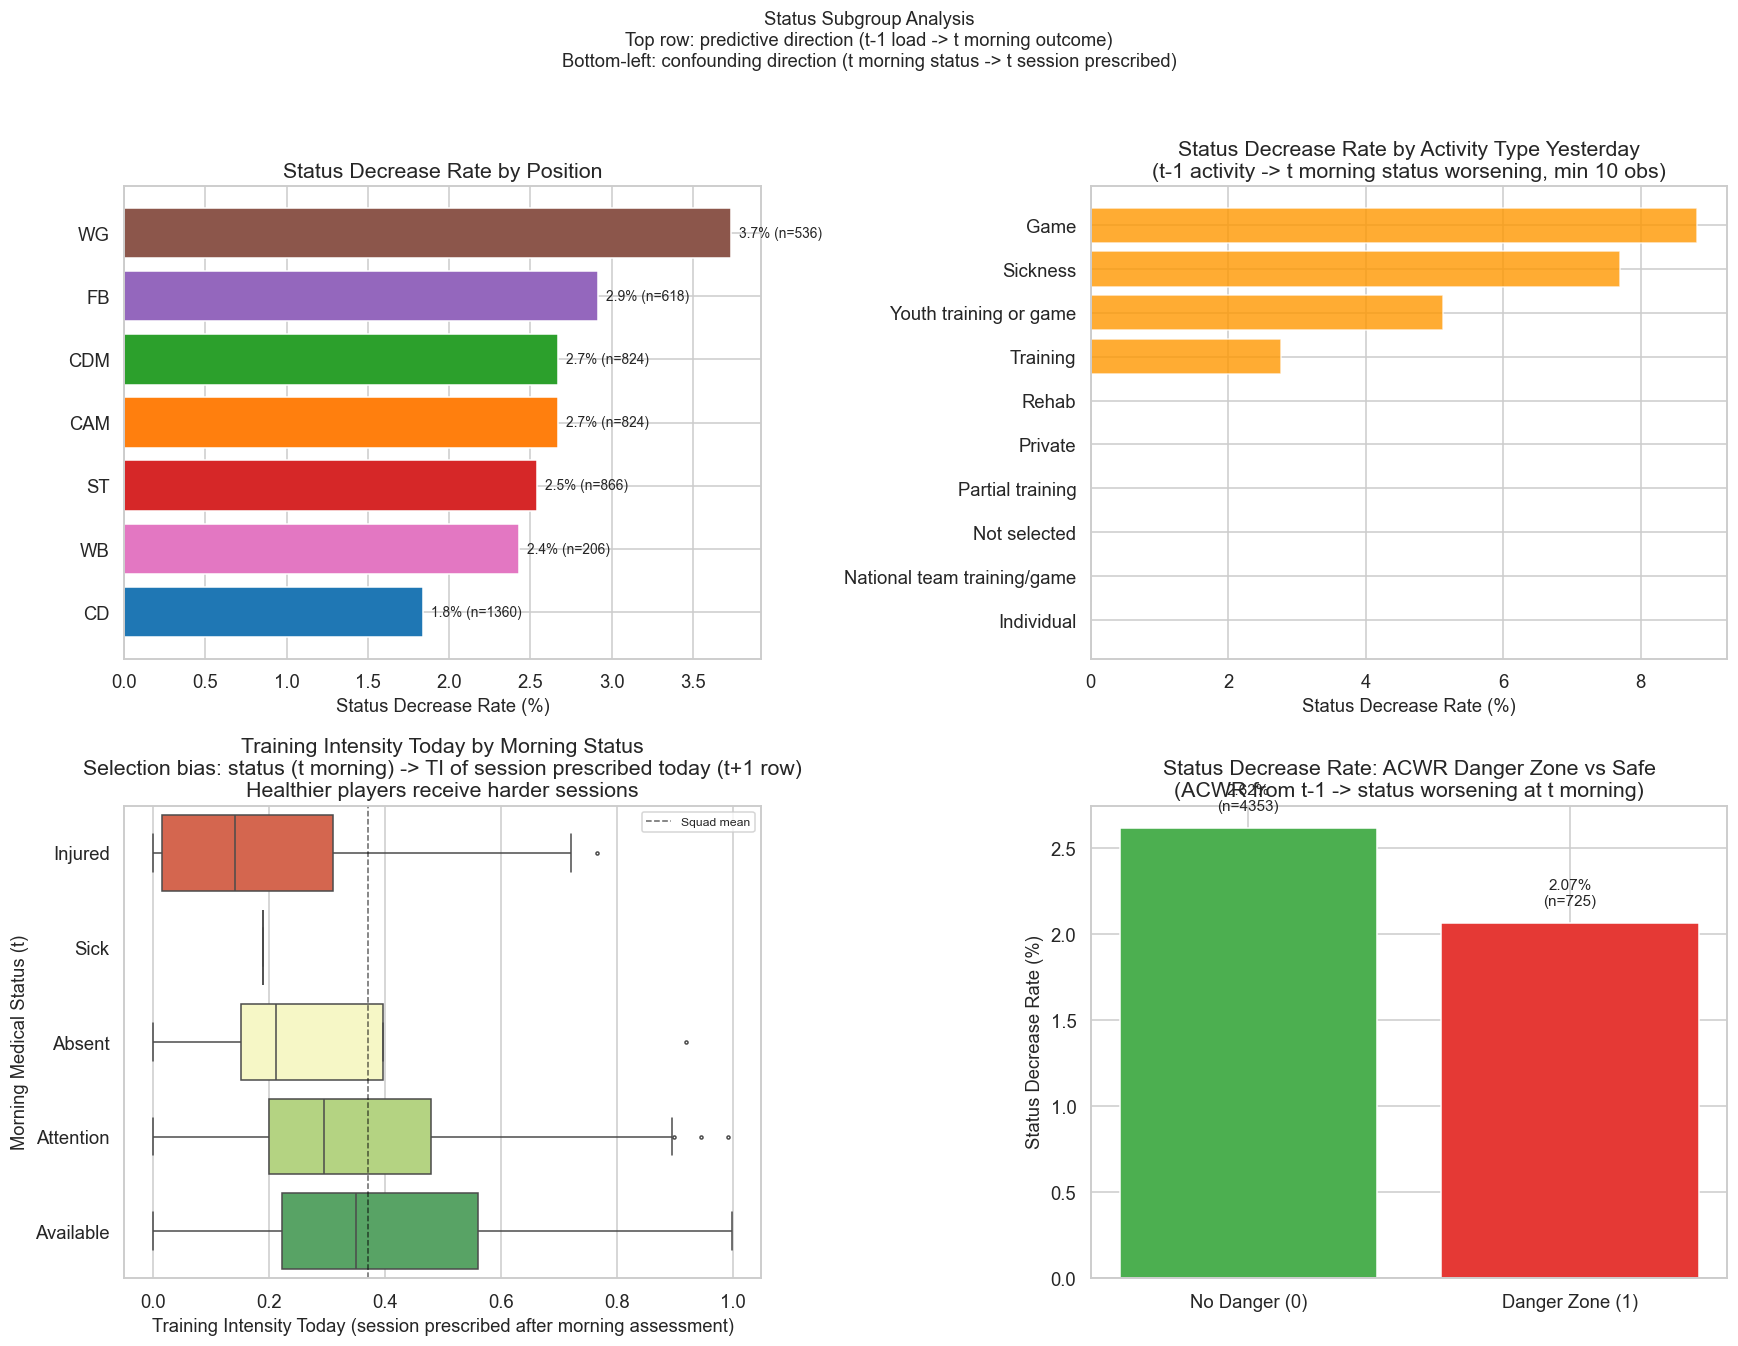

In [36]:
# Status Decrease rate by subgroup + confounding analysis
#
# Panel [0,0]: Status Decrease Rate by Position (no temporal issue)
# Panel [0,1]: Status Decrease Rate by Activity Type Yesterday (t-1 -> t, correct)
# Panel [1,0]: TI Today by Morning Status (confounding direction)
#              Status (morning t) -> TI prescribed today (= next row's TI Yesterday)
#              Shows selection bias: healthy players receive harder training.
# Panel [1,1]: Status Decrease Rate by ACWR Danger Zone (t-1 -> t, correct)

# Compute TI_today = training intensity of today's session
# = 'Training Intensity Yesterday' in the NEXT row (t+1) for each player
df_conf = df.sort_values(['Player ID', 'Date']).copy()
df_conf['TI Today'] = df_conf.groupby('Player ID')['Training Intensity Yesterday'].shift(-1)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# [0,0] Status Decrease Rate by Position
ax = axes[0, 0]
sd_by_pos = df.groupby('Position')['Status Decrease'].agg(['mean', 'count'])
sd_by_pos['pct'] = sd_by_pos['mean'] * 100
sd_by_pos = sd_by_pos.sort_values('pct', ascending=True)
ax.barh(sd_by_pos.index, sd_by_pos['pct'],
        color=[POS_PALETTE.get(p, '#999') for p in sd_by_pos.index], edgecolor='white')
ax.set_xlabel('Status Decrease Rate (%)')
ax.set_title('Status Decrease Rate by Position')
for i, (idx_name, row) in enumerate(sd_by_pos.iterrows()):
    ax.text(row['pct'] + 0.05, i, f'{row["pct"]:.1f}% (n={int(row["count"])})',
            va='center', fontsize=9)

# [0,1] Status Decrease Rate by Activity Type Yesterday (t-1 -> t morning)
ax = axes[0, 1]
sd_by_act = df.dropna(subset=['Activity Type Yesterday']).groupby(
    'Activity Type Yesterday')['Status Decrease'].agg(['mean', 'count'])
sd_by_act = sd_by_act[sd_by_act['count'] >= 10]
sd_by_act['pct'] = sd_by_act['mean'] * 100
sd_by_act = sd_by_act.sort_values('pct', ascending=True)
ax.barh(sd_by_act.index, sd_by_act['pct'], color='#FF9800', edgecolor='white', alpha=0.8)
ax.set_xlabel('Status Decrease Rate (%)')
ax.set_title('Status Decrease Rate by Activity Type Yesterday\n'
             '(t-1 activity -> t morning status worsening, min 10 obs)')

# [1,0] TI Today by Morning Status -- CONFOUNDING DIRECTION
# Status is the morning covariate (t); TI Today = session prescribed that same day
# (= Training Intensity Yesterday in the next row = t+1).
# This reveals selection bias: coaches prescribe harder sessions to healthier players.
ax = axes[1, 0]
conf_data = df_conf.dropna(subset=['Status', 'TI Today'])
status_order = (conf_data.groupby('Status')['TI Today'].median()
                .sort_values(ascending=True).index)
sns.boxplot(data=conf_data, y='Status', x='TI Today',
            order=status_order, ax=ax, palette='RdYlGn', fliersize=2)
ax.set_xlabel('Training Intensity Today (session prescribed after morning assessment)')
ax.set_ylabel('Morning Medical Status (t)')
ax.set_title('Training Intensity Today by Morning Status\n'
             'Selection bias: status (t morning) -> TI of session prescribed today (t+1 row)\n'
             'Healthier players receive harder sessions')
ax.axvline(conf_data['TI Today'].mean(), color='black',
           linestyle='--', linewidth=1, alpha=0.6, label='Squad mean')
ax.legend(fontsize=8)

# [1,1] Status Decrease Rate by ACWR Danger Zone (t-1 -> t morning)
ax = axes[1, 1]
sd_by_danger = df.dropna(subset=['Any ACWR Danger']).groupby(
    'Any ACWR Danger')['Status Decrease'].agg(['mean', 'count'])
sd_by_danger['pct'] = sd_by_danger['mean'] * 100
ax.bar(['No Danger (0)', 'Danger Zone (1)'], sd_by_danger['pct'],
       color=['#4CAF50', '#E53935'], edgecolor='white')
for i, (idx_name, row) in enumerate(sd_by_danger.iterrows()):
    ax.text(i, row['pct'] + 0.1, f'{row["pct"]:.2f}%\n(n={int(row["count"])})',
            ha='center', fontsize=10)
ax.set_ylabel('Status Decrease Rate (%)')
ax.set_title('Status Decrease Rate: ACWR Danger Zone vs Safe\n'
             '(ACWR from t-1 -> status worsening at t morning)')

plt.suptitle('Status Subgroup Analysis\n'
             'Top row: predictive direction (t-1 load -> t morning outcome)\n'
             'Bottom-left: confounding direction (t morning status -> t session prescribed)',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

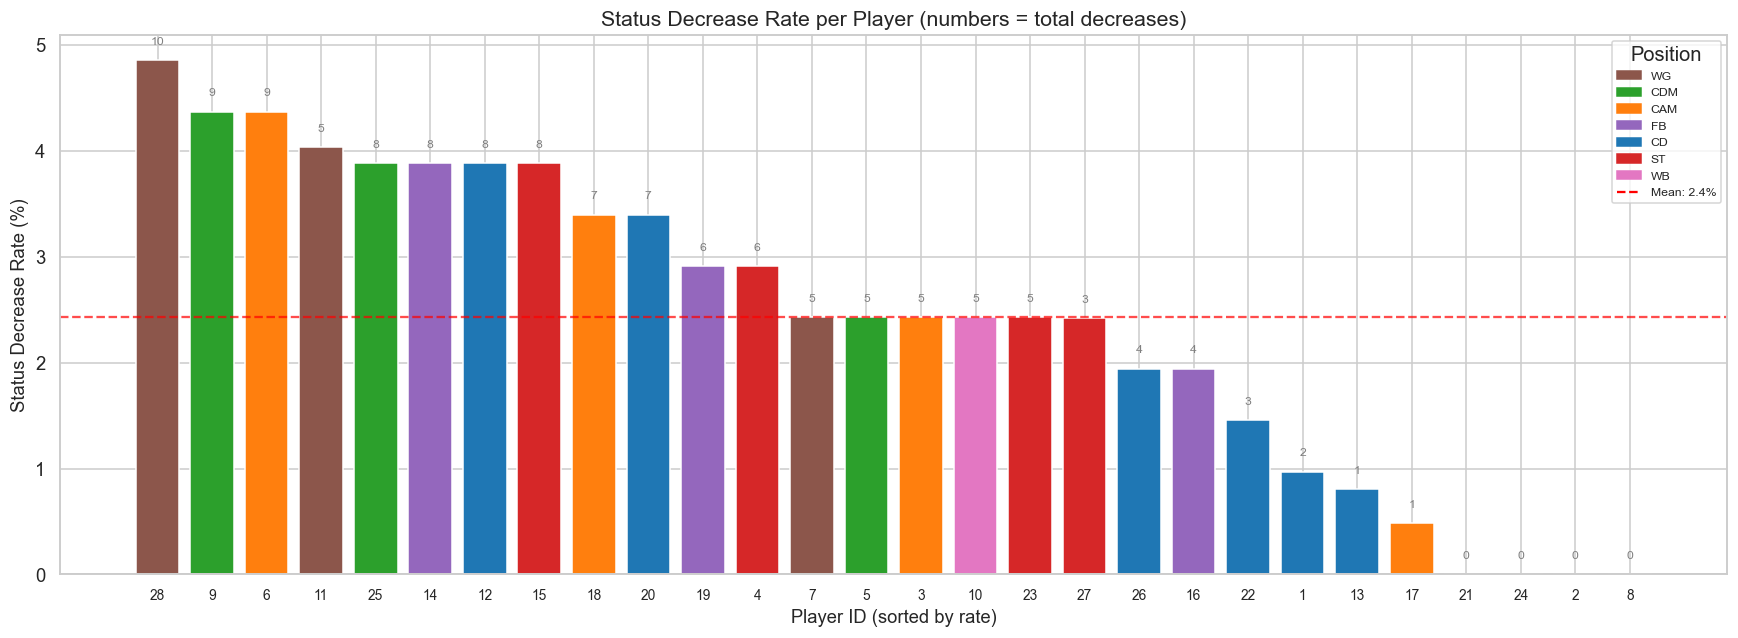

In [37]:
# Per-player Status Decrease rate
sd_player = df.groupby('Player ID')['Status Decrease'].agg(['mean', 'sum', 'count'])
sd_player['pct'] = sd_player['mean'] * 100
sd_player = sd_player.sort_values('pct', ascending=False)

fig, ax = plt.subplots(figsize=(16, 6))
bar_colors = [POS_PALETTE.get(player_pos.get(p, ''), '#999') for p in sd_player.index]
ax.bar(range(len(sd_player)), sd_player['pct'], color=bar_colors, edgecolor='white')
ax.set_xticks(range(len(sd_player)))
ax.set_xticklabels([str(p) for p in sd_player.index], fontsize=9)
for i, (pid, row) in enumerate(sd_player.iterrows()):
    ax.text(i, row['pct'] + 0.15, f'{int(row["sum"])}', ha='center', fontsize=8, color='grey')
ax.axhline(sd_player['pct'].mean(), color='red', linestyle='--', alpha=0.7,
           label=f'Mean: {sd_player["pct"].mean():.1f}%')
ax.set_xlabel('Player ID (sorted by rate)')
ax.set_ylabel('Status Decrease Rate (%)')
ax.set_title('Status Decrease Rate per Player (numbers = total decreases)')
ax.legend()

used_positions = player_pos.reindex(sd_player.index).unique()
legend_patches = [mpatches.Patch(color=POS_PALETTE.get(p, '#999'), label=p) for p in used_positions]
ax.legend(handles=legend_patches + [plt.Line2D([0], [0], color='red', linestyle='--', label=f'Mean: {sd_player["pct"].mean():.1f}%')],
          title='Position', loc='upper right', fontsize=8)

plt.tight_layout()
plt.show()

In [38]:
# Summary statistics
print('=' * 70)
print('PROCESSED DATA SUMMARY')
print('=' * 70)
print(f'Total observations:     {len(df):>8,}')
print(f'Unique players:         {df["Player ID"].nunique():>8}')
print(f'Date range:             {df["Date"].min().date()} to {df["Date"].max().date()}')
print(f'Total days:             {df["Date"].nunique():>8}')
print(f'Columns:                {df.shape[1]:>8}')
print()
print(f'Match days:             {df["Match Day"].sum() // df["Player ID"].nunique():>8}')
print(f'Rows with match perf:   {df["Match HID Per BIP Yesterday"].notna().sum():>8,} ({100*df["Match HID Per BIP Yesterday"].notna().sum()/len(df):.1f}%)')
print(f'Rows with Match Intensity: {df["Match Intensity Yesterday"].notna().sum():>5,} ({100*df["Match Intensity Yesterday"].notna().sum()/len(df):.1f}%)')
print(f'Match Intensity:        mean={df["Match Intensity Yesterday"].mean():.3f}, median={df["Match Intensity Yesterday"].median():.3f}')
print(f'Rows with TI:           {df["Training Intensity Yesterday"].notna().sum():>8,} ({100*df["Training Intensity Yesterday"].notna().sum()/len(df):.1f}%)')
print(f'Rows with wellness:     {df["Fatigue (z)"].notna().sum():>8,} ({100*df["Fatigue (z)"].notna().sum()/len(df):.1f}%)')
print()
print(f'Status Decrease rate:   {100*df["Status Decrease"].mean():.2f}% ({df["Status Decrease"].sum()} events)')
print(f'ACWR Danger rate:       {100*df["Any ACWR Danger"].mean():.1f}% (of non-NaN)')
print(f'Training Intensity:     mean={df["Training Intensity Yesterday"].mean():.3f}, median={df["Training Intensity Yesterday"].median():.3f}')
print('=' * 70)

PROCESSED DATA SUMMARY
Total observations:        5,234
Unique players:               28
Date range:             2025-07-27 to 2026-02-17
Total days:                  206
Columns:                      46

Match days:                   26
Rows with match perf:        362 (6.9%)
Rows with Match Intensity:   362 (6.9%)
Match Intensity:        mean=3.412, median=3.344
Rows with TI:              3,237 (61.8%)
Rows with wellness:        2,711 (51.8%)

Status Decrease rate:   2.56% (134 events)
ACWR Danger rate:       14.3% (of non-NaN)
Training Intensity:     mean=0.370, median=0.323
